# Comparativo Entre os 3 Melhores Modelos de ML e DL


## Sumário 

Este notebook compara os 3 melhores modelos do Modelos_ML.ipynb (escolhidos pela acurácia em GroupKFold(5)) e os 3 melhores do Modelos_Deep_learning.ipynb (1 MLP + 2 CNN).

| # | Tipo | Pipeline | Acc. (parent, GKF5) | Posição no Notebook de Origem |
|---|--------|----------|---------------------|--------------------|
| 1 | ML  | KNN(k=7) + features canal_com_rms + LDA shrinkage='auto' | 0.598 | Top-1 do Teste 5 |
| 2 | ML  | LogReg(L2) + features canal_com_rms (sem LDA) | 0.596 | Top-1 do Teste 2 |
| 3 | ML  | SVM(RBF) + features canal_com_rms + LDA sem shrinkage | 0.582 | Top-3 do Teste 5 |
| 4 | DL  | MLP(128-64-32) sobre features clássicas (z-score por sujeito) | 0.580 | Melhor MLP|
| 5 | DL  | CNN 2D sobre STFT (espectrograma direto, log-power) | 0.502 | Teste 9 do Dl |
| 6 | DL  | CNN 3D sobre STFT topográfico (3×5 grid C3/Cz/C4...) | 0.533 | Teste 10 do Dl |


## Estrutura

| Seção | Conteúdo |
|-------|----------|
| **0** | Configuração inicials |
| **A** | Definição dos 6 pipelines + execução de Cross-Validation |
| **B** | Matrizes de confusão por classe |
| **C** | Verificação de overfitting e underfitting |
| **D** | Testes de normalidade sobre os resultados (global + por modelo) |
| **E** | describe() das principais métricas |
| **F** | Verificação visual de normalidade |
| **G** | Teste de Tukey HSD + Friedman + Nemenyi + Wilcoxon |
| **H** | Análises comparativas + respostas ás RQs |


## 0. Configuração Incial

Esta seção configura e carrega tudo que o restante do notebook precisa.

### O que cada subseção faz

| Subseção | Função |
|----------|--------|
| 0.1 | Imports |
| 0.2 | Definição de paths |
| 0.3 | Função load_all_subjects() para carregar os arquivos .fif |
| 0.4 | Reconstrução das matrizes de features X_feat (sem RMS) e X_feat_rms (com RMS), com cache em pickle |


### 0.1 Imports



In [ ]:
import os
import pickle
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.signal as sp_signal
from scipy.integrate import trapezoid
from scipy.stats import (
    entropy as scipy_entropy,
    shapiro, normaltest, kstest, anderson,
    friedmanchisquare, wilcoxon,
    f_oneway, levene,
    probplot,
)

from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.libqsturng import psturng

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import (
    GroupKFold, cross_val_predict, learning_curve,
)
from sklearn.metrics import (
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve,
)

import mne

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(it, **kw):
        return it

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

SEED = 42
np.random.seed(SEED)

print('Setup OK')


Setup OK


### 0.2 Paths e cache


**Os 3 caches relevantes:**

| Arquivo | Conteúdo |
|---------|----------|
| X_feat_classical_v1.pkl     | Features clássicas (sem RMS)|
| X_feat_canal_com_rms.pkl    | Features clássicas com normalização RMS por canal|
| X_stft.pkl                  | Tensor STFT pré-computado|
| mp2_top6_oof_cache.pkl     |Cache com predições OOF + métricas por fold dos 6 modelos |


In [ ]:
# Mesmo caminho dos notebooks ML e DL. Ajuste se necessário.
OUTPUT_DIR      = Path(r"C:\Users\tiago\Downloads\Mini_Projeto_2_Tiago\data_eegmmidb\preprocessed_v2")
PER_SUBJECT_DIR = OUTPUT_DIR / "per_subject"
CACHE_DIR       = OUTPUT_DIR / "ml_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Caches usados neste notebook
TOP6_CACHE     = CACHE_DIR / "mp2_top6_oof_cache.pkl"
FEATURES_CACHE = CACHE_DIR / "X_feat_classical_v1.pkl"
RMS_CACHE      = CACHE_DIR / "X_feat_canal_com_rms.pkl"
STFT_CACHE     = CACHE_DIR / "X_stft.pkl"
LC_CACHE       = CACHE_DIR / "mp2_top6_learning_curves.pkl"

print(f'PER_SUBJECT_DIR: {PER_SUBJECT_DIR}')
print(f'TOP6_CACHE     : {TOP6_CACHE}  (existe? {TOP6_CACHE.exists()})')


PER_SUBJECT_DIR: C:\Users\tiago\Downloads\Mini_Projeto_2_Tiago\data_eegmmidb\preprocessed_v2\per_subject
TOP6_CACHE     : C:\Users\tiago\Downloads\Mini_Projeto_2_Tiago\data_eegmmidb\preprocessed_v2\ml_cache\mp2_top6_oof_cache.pkl  (existe? True)


### 0.3 Carregamento dos dados pré-processados

Lemos os arquivos .fif por sujeito (gerados na etapa de pré-processamento) e organizamos os dados em três estruturas principais, empilhando-os para análise posterior:

- **X**: shape (n_epochs, n_channels, n_times) => sinais de EEG já filtrados, segmentados, com ICA aplicada.
- **y**: rótulos binários => 0 = T1 (mão esquerda) e 1 = T2 (mão direita).
- **groups**: ID do sujeito de cada época.

In [ ]:
def load_all_subjects(per_subject_dir):
    """Le todos os *_allruns-epo.fif e retorna X, y, groups, runs, sfreq.

    Cada arquivo *_allruns-epo.fif* corresponde a um sujeito (S004, S014, ...).
    A funcao monta tensores empilhando todos os sujeitos.
    """
    fif_files = sorted(Path(per_subject_dir).glob('*_allruns-epo.fif'))
    if not fif_files:
        raise FileNotFoundError(
            f'Nenhum arquivo *_allruns-epo.fif em {per_subject_dir}.'
        )

    X_list, y_list, groups_list, runs_list = [], [], [], []
    sfreq_set = set()

    for fif_file in tqdm(fif_files, desc='Lendo .fif'):
        ep = mne.read_epochs(fif_file, preload=True, verbose='ERROR')
        Xs = ep.get_data()

        # T1=esq -> 0, T2=dir => 1 (mapeado pelo nome do evento)
        events = ep.events[:, -1]
        ev_id  = ep.event_id
        inv    = {v: k for k, v in ev_id.items()}
        ys     = np.array([1 if 'T2' in inv[e] else 0 for e in events], dtype=int)

        # ID do sujeito = primeiro token do nome do arquivo (ex: 'S004')
        subj_id = fif_file.stem.split('_')[0]
        gs = np.array([subj_id] * len(ys))

        # Run (vem do metadata se existir; senao 'r0')
        if hasattr(ep, 'metadata') and ep.metadata is not None and 'run' in ep.metadata.columns:
            rs = ep.metadata['run'].values
        else:
            rs = np.array(['r0'] * len(ys))

        X_list.append(Xs)
        y_list.append(ys)
        groups_list.append(gs)
        runs_list.append(rs)
        sfreq_set.add(int(ep.info['sfreq']))

    if len(sfreq_set) != 1:
        raise ValueError(f'sfreq inconsistente: {sfreq_set}')

    return (np.concatenate(X_list, axis=0),
            np.concatenate(y_list, axis=0),
            np.concatenate(groups_list, axis=0),
            np.concatenate(runs_list, axis=0),
            sfreq_set.pop())


# Carrega tudo
X, y, groups, runs, SFREQ = load_all_subjects(PER_SUBJECT_DIR)

# Lista de canais (mesma para todos os sujeitos)
_first_fif = sorted(Path(PER_SUBJECT_DIR).glob('*_allruns-epo.fif'))[0]
CH_NAMES = mne.read_epochs(_first_fif, preload=False, verbose='ERROR').info['ch_names']

print(f'\nX: {X.shape}   y: {y.shape}   groups: {len(np.unique(groups))} sujeitos')
print(f'SFREQ: {SFREQ} Hz   |   Canais ({len(CH_NAMES)}): {CH_NAMES}')
print(f'Balanco: T1={np.sum(y==0)}  T2={np.sum(y==1)}  ({100*np.mean(y==0):.0f}%/{100*np.mean(y==1):.0f}%)')


Lendo .fif:   0%|          | 0/10 [00:00<?, ?it/s]


X: (450, 15, 673)   y: (450,)   groups: 10 sujeitos
SFREQ: 160 Hz   |   Canais (15): ['FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C3', 'C1', 'Cz', 'C2', 'C4', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4']
Balanco: T1=225  T2=225  (50%/50%)


### 0.4 Extração das features clássicas

As 3 melhores ML usam features clássicas com normalização RMS por canal, e a MLP usa as mesmas features sem RMS. 

**As 7 features por canal (totalizando 7 × 15 canais = 105 features por época):**

1. **Potência relativa em mu (8–13 Hz):**  banda do ERD/ERS sensoriomotor.
2. **Potência relativa em beta_low (13–20 Hz)**.
3. **Potência relativa em beta_high (20–30 Hz):** relacionada ao rebote pós-movimento.
4. **Variância do sinal no tempo:** proxy de energia total.
5. **Hjorth Mobility:** proxy de frequência média.
6. **Hjorth Complexity:** proxy da regularidade espectral.
7. **Entropia espectral (Shannon sobre PSD normalizada):** proxy de "quão concentrada" é a energia em poucas frequências.

A normalização RMS por canal divide cada sinal por seu RMS antes da extração, preservando a forma espectral e removendo o efeito de magnitude absoluta (artefatos de impedância, etc.).

In [ ]:
# Bandas espectrais 
BANDS = {
    'mu':         (8, 13),
    'beta_low':   (13, 20),
    'beta_high':  (20, 30),
}


def bandpower_welch(sig, sfreq, fmin, fmax):
    """Potencia em uma banda via metodo de Welch + integracao trapezoidal."""
    freqs, psd = sp_signal.welch(sig, fs=sfreq, nperseg=min(256, len(sig)))
    mask = (freqs >= fmin) & (freqs <= fmax)
    return trapezoid(psd[mask], freqs[mask])


def hjorth_params(sig):
    """Retorna (Activity, Mobility, Complexity)."""
    activity = np.var(sig)
    d1, d2 = np.diff(sig), np.diff(np.diff(sig))
    var_d1, var_d2 = np.var(d1), np.var(d2)
    mobility   = np.sqrt(var_d1 / (activity + 1e-12))
    complexity = np.sqrt(var_d2 / (var_d1 + 1e-12)) / (mobility + 1e-12)
    return activity, mobility, complexity


def spectral_entropy(sig, sfreq):
    """Entropia de Shannon da PSD normalizada."""
    freqs, psd = sp_signal.welch(sig, fs=sfreq, nperseg=min(256, len(sig)))
    psd_norm = psd / (psd.sum() + 1e-12)
    return scipy_entropy(psd_norm)


def rms_normalize(sig):
    """Divide o sinal pela sua RMS. Preserva a forma espectral, remove a amplitude."""
    rms = np.sqrt(np.mean(sig ** 2))
    return sig / (rms + 1e-12)


def _features_1ch(sig, sfreq, bands, rms_correction=False):
    """Calcula as 7 features em um sinal 1D (1 epoca de 1 canal)."""
    if rms_correction:
        sig = rms_normalize(sig)
    bps = {b: bandpower_welch(sig, sfreq, lo, hi) for b, (lo, hi) in bands.items()}
    total = sum(bps.values()) + 1e-12
    feats = [bps[b] / total for b in bands]      # 3 potencias relativas
    feats.append(np.var(sig))                     # variancia
    _, mob, comp = hjorth_params(sig)
    feats.extend([mob, comp])                     # Hjorth mob, comp
    feats.append(spectral_entropy(sig, sfreq))    # entropia espectral
    return np.array(feats)


def extract_features(X, sfreq, rms_correction=False):
    """X: (n_ep, n_ch, n_t) -> (n_ep, 7 * n_ch)."""
    n_ep, n_ch, _ = X.shape
    out = np.zeros((n_ep, n_ch * 7), dtype=np.float64)
    desc = 'feat_rms' if rms_correction else 'feat'
    for ei, ep in enumerate(tqdm(X, desc=desc)):
        for ci in range(n_ch):
            out[ei, ci*7:(ci+1)*7] = _features_1ch(
                ep[ci], sfreq, BANDS, rms_correction
            )
    return out


def _load_or_extract(cache_path, rms):
    """Helper: carrega de cache ou extrai e salva."""
    if cache_path.exists():
        print(f'Carregando do cache: {cache_path.name}')
        with open(cache_path, 'rb') as f:
            obj = pickle.load(f)
        return obj['X_feat'] if isinstance(obj, dict) else obj
    print(f'Extraindo (rms={rms})...')
    Xf = extract_features(X, SFREQ, rms_correction=rms)
    with open(cache_path, 'wb') as f:
        pickle.dump({'X_feat': Xf, 'feat_names': None} if not rms else Xf, f)
    return Xf


X_feat     = _load_or_extract(FEATURES_CACHE, rms=False)   # MLP
X_feat_rms = _load_or_extract(RMS_CACHE,      rms=True)    # 3 ML

# Sanity (substituir possiveis NaN/Inf por 0)
for arr_name, arr in [('X_feat', X_feat), ('X_feat_rms', X_feat_rms)]:
    bad = ~np.isfinite(arr)
    if bad.any():
        print(f'{arr_name}: {bad.sum()} NaN/Inf -> substituindo por 0')
        arr[bad] = 0.0

print(f'\nX_feat     shape: {X_feat.shape}')
print(f'X_feat_rms shape: {X_feat_rms.shape}')


Carregando do cache: X_feat_classical_v1.pkl
Carregando do cache: X_feat_canal_com_rms.pkl

X_feat     shape: (450, 105)
X_feat_rms shape: (450, 105)


## A. Definição dos 6 pipelines e cross-validation unificada

Todos os 6 modelos são submetidos a **GroupKFold(5)** — 5 folds garantindo que nenhum sujeito apareça simultaneamente em treino e teste, evitando data leakage. Esta é a única seção que faz computação pesada; as seções B–H apenas lêem o cache `mp2_top6_oof_cache.pkl`.

### Por que GroupKFold(5) e não LOSO?

| | LOSO (10 folds) | GroupKFold(5) |
|---|---|---|
| Sujeitos por fold de teste | 1 | 2 |
| Estimativa por fold | Maior variância (n=45 ép./fold) | Menor variância (n=90 ép./fold) |
| Tempo de treino | 10 ajustes | 5 ajustes |
| Comparabilidade entre 6 modelos | Boa | **Melhor** (mais épocas/fold reduz ruído inter-fold) |

Para a comparação estatística entre modelos, GKF(5) é preferível porque cada modelo é avaliado nas **mesmas 5 partições** — pré-requisito do **teste de Friedman** (medidas repetidas).


### A-1) Pipelines de Machine Learning

Os 3 melhores ML do parent. Em todos:

- StandardScaler ajustado somente no treino de cada fold.
- Para os pipelines com LDA como redução supervisionada (1D), o LDA também é ajustado por fold.

In [ ]:
# ML #1: KNN(k=7) + LDA(shrinkage='auto')
PIPE_ML1 = Pipeline([
    ('scaler', StandardScaler()),
    ('lda',    LDA(solver='lsqr', shrinkage='auto')),
    ('clf',    KNeighborsClassifier(n_neighbors=7, n_jobs=-1)),
])

# ML #2: LogReg(L2) sem LDA 
PIPE_ML2 = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(C=1.0, max_iter=2000, random_state=SEED)),
])

# ML #3: SVM(RBF) + LDA(sem shrinkage)
PIPE_ML3 = Pipeline([
    ('scaler', StandardScaler()),
    ('lda',    LDA(solver='svd')),
    ('clf',    SVC(kernel='rbf', C=1.0, gamma='scale',
                   probability=True, random_state=SEED)),
])

ML_PIPES = {
    'ML1: KNN+RMS+LDA-auto':  (PIPE_ML1, X_feat_rms),
    'ML2: LogReg+RMS':        (PIPE_ML2, X_feat_rms),
    'ML3: SVM-RBF+RMS+LDA':   (PIPE_ML3, X_feat_rms),
}

print('Pipelines ML configurados:')
for name, (pipe, _) in ML_PIPES.items():
    print(f'  {name:<28s} => {[s[0] for s in pipe.steps]}')


Pipelines ML configurados:
  ML1: KNN+RMS+LDA-auto        -> ['scaler', 'lda', 'clf']
  ML2: LogReg+RMS              -> ['scaler', 'clf']
  ML3: SVM-RBF+RMS+LDA         -> ['scaler', 'lda', 'clf']


### A-2) MLP (DL top 1) - replicação da MLP-Keras-v2 via sklearn

Arquitetura: Dense(128) => Dense(64) => Dense(32) => Dense(1, sigmoid), com BatchNorm e Dropout.

**Por que sklearn em vez de Keras?** O notebook original já demonstrou (no Cell 34: Diferença acc (sklearn - Keras-v2) em GKF: -0.020) que as duas implementações concordam dentro de ±0.02 acc. Usamos MLPClassifier aqui por:

- Compatibilidade direta com Pipeline e cross_val_predict.
- early_stopping=True interno (mesma lógica da Keras-v2).
- Sem dependência de GPU.

A diferença é estatisticamente irrelevante para esta análise comparativa.

In [6]:
PIPE_MLP = Pipeline([
    ('scaler', RobustScaler()),
    ('clf',    MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        learning_rate_init=1e-3,
        alpha=1e-4,                 # L2 leve
        batch_size=64,
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=15,
        random_state=SEED,
    )),
])

print('MLP arquitetura: (128, 64, 32) com early stopping interno')


MLP arquitetura: (128, 64, 32) com early stopping interno


### A-3) CNN 2D sobre STFT (DL #2)

A entrada de cada época é um espectrograma log-power por canal (STFT com nperseg=128, noverlap=64, banda 8-30 Hz). Isso permite que a CNN aprenda padrões tempo-frequência diretamente do sinal bruto, sem features handcrafted.

**Formatos de entrada:** shape (N, F, T, C) => (épocas, frequências, tempo, canais).

**Arquitetura:** Conv2D(16) => BN => ReLU => MaxPool => Dropout => Conv2D(32) => BN => ReLU => GlobalAvgPool => Dense(32) => Dropout => Dense(1, sigmoid).

In [7]:
# Verifica TensorFlow
HAS_KERAS = True
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    tf.random.set_seed(SEED)
    print(f'TensorFlow {tf.__version__} OK')
except ImportError:
    HAS_KERAS = False
    print('AVISO: TensorFlow ausente -- DL #2 e DL #3 (CNNs) serao puladas.')


TensorFlow 2.21.0 OK


In [ ]:
# STFT por canal (cache em pickle) 
from scipy.signal import spectrogram

def compute_stft_tensor(X, sfreq, fmin=8, fmax=30, nperseg=128, noverlap=64):
    """X: (N, C, T) -> (N, C, F, T_stft) -- log-power STFT na banda [fmin, fmax]."""
    n_ep, n_ch, _ = X.shape
    out = []
    for ep in range(n_ep):
        ch_specs = []
        for ch in range(n_ch):
            f, t, Sxx = spectrogram(X[ep, ch], fs=sfreq,
                                    nperseg=nperseg, noverlap=noverlap,
                                    scaling='density', mode='psd')
            mask = (f >= fmin) & (f <= fmax)
            Sxx = np.log(Sxx[mask] + 1e-10)
            ch_specs.append(Sxx)
        out.append(np.stack(ch_specs, axis=0))
    return np.array(out)


# Pre-computa o tensor STFT 1x
if STFT_CACHE.exists():
    print(f'Carregando X_stft do cache: {STFT_CACHE.name}')
    with open(STFT_CACHE, 'rb') as f:
        X_stft = pickle.load(f)
else:
    print('Calculando STFT por epoca...')
    X_stft = compute_stft_tensor(X, SFREQ)
    with open(STFT_CACHE, 'wb') as f:
        pickle.dump(X_stft, f)

print(f'X_stft shape: {X_stft.shape}  (N, C, F, T)')


def build_cnn2d_stft(input_shape, seed=SEED):
    """CNN 2D do Teste 9 -- entrada (F, T, C)."""
    keras.utils.set_random_seed(seed)
    inp = keras.Input(shape=input_shape)
    x = layers.Conv2D(16, (3, 3), padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    m = keras.Model(inp, out, name='CNN2D_STFT')
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='binary_crossentropy', metrics=['accuracy'])
    return m


Carregando X_stft do cache: X_stft.pkl
X_stft shape: (450, 15, 18, 9)  (N, C, F, T)


### A-4) CNN 3D sobre STFT topográfico (DL #3)

Combina a ideia de espectrograma com a topografia espacial: os 15 canais são organizados num grid 3×5 que reflete a posição real no escalpo (linha de cima = FC, do meio = C, de baixo = CP).

**Formato de entrada:** shape (N, rows, cols, F, T) = (450, 3, 5, 18, 9) => a CNN 3D "vê" simultaneamente a topografia e o espectrograma.

**Arquitetura:** Conv3D(16) => MaxPool3D => Conv3D(32) => MaxPool3D => GlobalAvgPool3D => Dense(32) => Dropout(0.5) => Dense(1).

In [ ]:
# Grid topografico 
GRIDS = {
    21: [['FC5','FC3','FC1','FCz','FC2','FC4','FC6'],
         ['C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6'],
         ['CP5','CP3','CP1','CPz','CP2','CP4','CP6']],
    15: [['FC3','FC1','FCz','FC2','FC4'],
         ['C3', 'C1', 'Cz', 'C2', 'C4'],
         ['CP3','CP1','CPz','CP2','CP4']],
}


def to_topomap_5d(X_stft, ch_names):
    """(N, C, F, T) -> (N, rows, cols, F, T)"""
    N, C, F, T = X_stft.shape
    grid = GRIDS[C]
    rows, cols = len(grid), len(grid[0])
    ch_to_idx = {ch: i for i, ch in enumerate(ch_names)}
    X_topo = np.zeros((N, rows, cols, F, T), dtype=np.float32)
    for r in range(rows):
        for c in range(cols):
            ch = grid[r][c]
            if ch in ch_to_idx:
                X_topo[:, r, c] = X_stft[:, ch_to_idx[ch]]
    return X_topo


def build_cnn3d_topo(input_shape, seed=SEED):
    """CNN 3D do Teste 10 -- entrada (rows, cols, F, T)."""
    keras.utils.set_random_seed(seed)
    inp = keras.Input(shape=input_shape)

    x = layers.Conv3D(16, (2,2,3), padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling3D((1,1,2))(x)

    x = layers.Conv3D(32, (2,2,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling3D((1,1,2))(x)

    x = layers.GlobalAveragePooling3D()(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    m = keras.Model(inp, out, name='CNN3D_topo')
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='binary_crossentropy', metrics=['accuracy'])
    return m


if HAS_KERAS:
    X_topo = to_topomap_5d(X_stft, CH_NAMES)
    print(f'X_topo shape: {X_topo.shape}  (N, rows, cols, F, T)')


X_topo shape: (450, 3, 5, 18, 9)  (N, rows, cols, F, T)


### A-5) Funções de avaliação 


#### evaluate_sklearn_pipe(pipe, X, y, groups, cv)
Avalia um pipeline sklearn com:
1. **cross_val_predict(method='predict'):** para obter as predições OOF (necessárias para a matriz de confusão B).
2. **cross_val_predict(method='predict_proba'):** para o score contínuo (necessário para AUC e ROC).
3. **Loop manual fold-a-fold:** para coletar train_acc em cada fold (necessário para o gap de overfitting C.1), cross_val_predict não retorna o desempenho de treino.

#### evaluate_keras_cnn(...)
Loop manual para CNNs (Keras não é totalmente sklearn-compatível). Aplica RobustScaler flatten-then-reshape e usa EarlyStopping interno em 20% dos dados de treino.

In [ ]:
def _fix_lda_step(step):
    """Migra LDA para solver compativel com seu shrinkage atual."""
    if not isinstance(step, LDA):
        return step
    shrinkage = getattr(step, 'shrinkage', None)
    cov_estim = getattr(step, 'covariance_estimator', None)
    if shrinkage is not None or cov_estim is not None:
        step.set_params(solver='eigen')   # eigen aceita shrinkage
    else:
        step.set_params(solver='svd')     # svd e mais rapido sem shrinkage
    return step


def _fix_pipeline_for_cv(pipe):
    """Clona um pipeline e ajusta o solver dos LDAs internos."""
    pipe = clone(pipe)
    if isinstance(pipe, Pipeline):
        new_steps = []
        for name, step in pipe.steps:
            step = clone(step)
            step = _fix_lda_step(step)
            new_steps.append((name, step))
        return Pipeline(new_steps, memory=pipe.memory, verbose=pipe.verbose)
    return pipe


def evaluate_sklearn_pipe(pipe, X_data, y, groups, cv):
    """
    Avalia um pipeline sklearn com GroupKFold.
    Retorna {oof_preds, y_score, per_fold} - onde per_fold tem train_acc + 6 metricas de teste.
    """
    pipe = _fix_pipeline_for_cv(pipe)

    X_data = np.asarray(X_data)
    y      = np.asarray(y).ravel()
    groups = np.asarray(groups).ravel()

    # OOF labels e probabilidades
    oof_preds = cross_val_predict(pipe, X_data, y, groups=groups, cv=cv,
                                   method='predict', n_jobs=1)
    try:
        y_proba = cross_val_predict(pipe, X_data, y, groups=groups, cv=cv,
                                    method='predict_proba', n_jobs=1)
        y_score = y_proba[:, 1] if y_proba.ndim == 2 and y_proba.shape[1] > 1 else y_proba.ravel()
    except Exception:
        try:
            y_score = cross_val_predict(pipe, X_data, y, groups=groups, cv=cv,
                                        method='decision_function', n_jobs=1)
        except Exception:
            y_score = None

    # Loop manual para train_acc + per-fold metrics
    rows = []
    for fold_idx, (tr, te) in enumerate(cv.split(X_data, y, groups), start=1):
        est = clone(pipe)
        est.fit(X_data[tr], y[tr])

        y_tr_hat = est.predict(X_data[tr])
        y_te_hat = est.predict(X_data[te])

        try:
            sc = (est.predict_proba(X_data[te])[:, 1]
                  if hasattr(est, 'predict_proba')
                  else est.decision_function(X_data[te]))
        except Exception:
            sc = None

        rows.append({
            'fold':         fold_idx,
            'train_acc':    accuracy_score(y[tr], y_tr_hat),
            'test_acc':     accuracy_score(y[te], y_te_hat),
            'test_bal_acc': balanced_accuracy_score(y[te], y_te_hat),
            'test_prec':    precision_score(y[te], y_te_hat, zero_division=0),
            'test_rec':     recall_score(y[te], y_te_hat, zero_division=0),
            'test_f1':      f1_score(y[te], y_te_hat, zero_division=0),
            'test_auc':     (roc_auc_score(y[te], sc) if sc is not None
                              and len(np.unique(y[te])) > 1 else np.nan),
        })

    return {
        'oof_preds': oof_preds,
        'y_score':   y_score,
        'per_fold':  pd.DataFrame(rows),
    }


def evaluate_keras_cnn(model_builder, X_tensor, y, groups, cv,
                       n_epochs=40, batch_size=16, val_frac=0.2,
                       name='cnn'):
    """Loop manual para CNNs Keras. Coleta history para plot loss x epoch (Secao C)."""
    folds = list(cv.split(X_tensor, y, groups))
    n = len(y)
    oof_probs = np.zeros(n, dtype=float)
    oof_preds = -np.ones(n, dtype=int)
    histories = []
    rows = []

    for k, (tr, te) in enumerate(folds):
        keras.backend.clear_session()
        keras.utils.set_random_seed(SEED + k)

        Xtr, Xte = X_tensor[tr], X_tensor[te]

        # RobustScaler em flatten => reshape (mesma estrategia do parent)
        shp_tr, shp_te = Xtr.shape, Xte.shape
        scl = RobustScaler().fit(Xtr.reshape(len(Xtr), -1))
        Xtr = scl.transform(Xtr.reshape(len(Xtr), -1)).reshape(shp_tr).astype(np.float32)
        Xte = scl.transform(Xte.reshape(len(Xte), -1)).reshape(shp_te).astype(np.float32)

        # Inner val: 20% aleatorio do treino
        rng = np.random.RandomState(SEED + k)
        perm = rng.permutation(len(tr))
        n_val = int(val_frac * len(tr))
        Xt, yt = Xtr[perm[n_val:]], y[tr][perm[n_val:]]
        Xv, yv = Xtr[perm[:n_val]], y[tr][perm[:n_val]]

        model = model_builder(Xt.shape[1:], seed=SEED + k)
        h = model.fit(Xt, yt, validation_data=(Xv, yv),
                      epochs=n_epochs, batch_size=batch_size,
                      verbose=0, shuffle=True,
                      callbacks=[keras.callbacks.EarlyStopping(
                          monitor='val_loss', patience=8,
                          restore_best_weights=True)])
        histories.append(h.history)

        proba_te = model.predict(Xte, verbose=0).ravel()
        proba_tr = model.predict(Xtr, verbose=0).ravel()
        pred_te = (proba_te >= 0.5).astype(int)
        pred_tr = (proba_tr >= 0.5).astype(int)

        oof_probs[te] = proba_te
        oof_preds[te] = pred_te

        rows.append({
            'fold':         k + 1,
            'train_acc':    accuracy_score(y[tr], pred_tr),
            'test_acc':     accuracy_score(y[te], pred_te),
            'test_bal_acc': balanced_accuracy_score(y[te], pred_te),
            'test_prec':    precision_score(y[te], pred_te, zero_division=0),
            'test_rec':     recall_score(y[te], pred_te, zero_division=0),
            'test_f1':      f1_score(y[te], pred_te, zero_division=0),
            'test_auc':     (roc_auc_score(y[te], proba_te)
                              if len(np.unique(y[te])) > 1 else np.nan),
        })
        print(f'  [{name}] fold {k+1}/{len(folds)}: '
              f'tr_acc={rows[-1]["train_acc"]:.3f}  '
              f'te_acc={rows[-1]["test_acc"]:.3f}  '
              f'auc={rows[-1]["test_auc"]:.3f}')

        del model

    return {
        'oof_preds': oof_preds,
        'y_score':   oof_probs,
        'per_fold':  pd.DataFrame(rows),
        'histories': histories,
    }


### A-6) Execuçãocom todos os 6 modelos

Roda 1× e cacheia em pickle. Para forçar re-execução, apague mp2_top6_oof_cache.pkl.

**Observação sobre a seed da MLP.** Como MLPClassifier é estocástico (Adam + early stopping interno em 20% do treino), a acurácia pode variar ±0.03 entre execuções com seeds diferentes mesmo dentro do range esperado. O notebook original rodava ensemble de 3 seeds para estabilizar, aqui usamos seed única (= 42) para simplicidade, o ranking final é estável o suficiente para a comparação estatística.

In [ ]:
CV = GroupKFold(n_splits=5)

if TOP6_CACHE.exists():
    print(f'Cache encontrado: {TOP6_CACHE.name} - carregando.')
    with open(TOP6_CACHE, 'rb') as f:
        ALL_RESULTS = pickle.load(f)
else:
    print('Cache nao encontrado - rodando os 6 modelos sob GroupKFold(5).\n')
    ALL_RESULTS = {}

    # 3 ML
    for name, (pipe, X_data) in ML_PIPES.items():
        print(f'--- {name} ---')
        ALL_RESULTS[name] = evaluate_sklearn_pipe(pipe, X_data, y, groups, CV)

    # MLP (sklearn)
    print(f'\n--- DL1: MLP (sklearn) ---')
    ALL_RESULTS['DL1: MLP-128-64-32'] = evaluate_sklearn_pipe(
        PIPE_MLP, X_feat, y, groups, CV
    )

    # CNNs (Keras)
    if HAS_KERAS:
        print(f'\n--- DL2: CNN 2D STFT ---')
        X_cnn2d = np.transpose(X_stft, (0, 2, 3, 1)).astype(np.float32)
        ALL_RESULTS['DL2: CNN2D-STFT'] = evaluate_keras_cnn(
            build_cnn2d_stft, X_cnn2d, y, groups, CV,
            n_epochs=40, batch_size=16, name='CNN2D')

        print(f'\n--- DL3: CNN 3D topo ---')
        ALL_RESULTS['DL3: CNN3D-topo'] = evaluate_keras_cnn(
            build_cnn3d_topo, X_topo, y, groups, CV,
            n_epochs=40, batch_size=8, name='CNN3D')

    with open(TOP6_CACHE, 'wb') as f:
        pickle.dump(ALL_RESULTS, f)
    print(f'\nCache salvo: {TOP6_CACHE}')

# Resumo
print('\n' + '=' * 60)
print('RESUMO DOS 6 MODELOS (GroupKFold 5):')
print('=' * 60)
for name, res in ALL_RESULTS.items():
    pf = res['per_fold']
    print(f'  {name:<28s}  ACC = {pf["test_acc"].mean():.3f} '
          f'(+- {pf["test_acc"].std():.3f})    AUC = {pf["test_auc"].mean():.3f}')


Cache encontrado: mp2_top6_oof_cache.pkl -- carregando.

RESUMO DOS 6 MODELOS (GroupKFold 5):
  ML1: KNN+RMS+LDA-auto         ACC = 0.598 (+- 0.047)    AUC = 0.618
  ML2: LogReg+RMS               ACC = 0.596 (+- 0.065)    AUC = 0.599
  ML3: SVM-RBF+RMS+LDA          ACC = 0.582 (+- 0.038)    AUC = 0.592
  DL1: MLP-128-64-32            ACC = 0.513 (+- 0.047)    AUC = 0.537
  DL2: CNN2D-STFT               ACC = 0.551 (+- 0.054)    AUC = 0.609
  DL3: CNN3D-topo               ACC = 0.516 (+- 0.043)    AUC = 0.532


### A-7) Tabela-resumo e DataFrame "long-form"

A LONG é uma tabela em formato longo (uma linha por modelo×fold×métrica) usada por todas as análises subsequentes. 

In [12]:
# Tabela compacta com media (dp) por metrica
rows_summary = []
for name, res in ALL_RESULTS.items():
    pf = res['per_fold']
    rows_summary.append({
        'modelo':         name,
        'train_acc':      f'{pf["train_acc"].mean():.3f}',
        'accuracy':       f'{pf["test_acc"].mean():.3f} ({pf["test_acc"].std():.3f})',
        'balanced_acc':   f'{pf["test_bal_acc"].mean():.3f} ({pf["test_bal_acc"].std():.3f})',
        'precision':      f'{pf["test_prec"].mean():.3f} ({pf["test_prec"].std():.3f})',
        'recall':         f'{pf["test_rec"].mean():.3f} ({pf["test_rec"].std():.3f})',
        'f1':             f'{pf["test_f1"].mean():.3f} ({pf["test_f1"].std():.3f})',
        'roc_auc':        f'{pf["test_auc"].mean():.3f} ({pf["test_auc"].std():.3f})',
    })
SUMMARY = pd.DataFrame(rows_summary).set_index('modelo')

print('=== Tabela-resumo dos 6 modelos (media (dp) entre folds) ===\n')
print(SUMMARY.drop(columns=['train_acc']).to_string())


# DataFrame long-form que sera usado nas secoes B-H
long_rows = []
for name, res in ALL_RESULTS.items():
    pf = res['per_fold']
    for col, lab in [('test_acc',     'accuracy'),
                     ('test_bal_acc', 'bal_acc'),
                     ('test_prec',    'precision'),
                     ('test_rec',     'recall'),
                     ('test_f1',      'f1'),
                     ('test_auc',     'roc_auc')]:
        for fk, v in zip(pf['fold'], pf[col]):
            long_rows.append({'modelo': name, 'fold': fk,
                              'metric': lab, 'value': v})
LONG = pd.DataFrame(long_rows)

print(f'\nLONG shape: {LONG.shape}  (modelos x folds x metricas)')


=== Tabela-resumo dos 6 modelos (media (dp) entre folds) ===

                            accuracy   balanced_acc      precision         recall             f1        roc_auc
modelo                                                                                                         
ML1: KNN+RMS+LDA-auto  0.598 (0.047)  0.600 (0.046)  0.600 (0.030)  0.585 (0.170)  0.582 (0.102)  0.618 (0.065)
ML2: LogReg+RMS        0.596 (0.065)  0.596 (0.064)  0.595 (0.058)  0.606 (0.133)  0.594 (0.090)  0.599 (0.063)
ML3: SVM-RBF+RMS+LDA   0.582 (0.038)  0.584 (0.039)  0.591 (0.045)  0.567 (0.142)  0.569 (0.075)  0.592 (0.035)
DL1: MLP-128-64-32     0.513 (0.047)  0.516 (0.047)  0.513 (0.053)  0.483 (0.266)  0.469 (0.151)  0.537 (0.088)
DL2: CNN2D-STFT        0.551 (0.054)  0.554 (0.056)  0.646 (0.207)  0.376 (0.370)  0.385 (0.228)  0.609 (0.111)
DL3: CNN3D-topo        0.516 (0.043)  0.515 (0.044)  0.519 (0.043)  0.643 (0.296)  0.546 (0.124)  0.532 (0.066)

LONG shape: (180, 4)  (modelos x folds x 

## B) Matrizes de confusão por classe - TP/TN/FP/FN

### Definições

Em classificação binária, a matriz de confusão de cada modelo decompõe os 450 exemplos OOF em 4 categorias:

| | **Pred T1 (esq)** | **Pred T2 (dir)** |
|---|---|---|
| **Real T1 (esq)** | **TN** - acerto da classe esquerda | **FP** - falso T2 (erro tipo I) |
| **Real T2 (dir)** | **FN** - falso T1 (erro tipo II) | **TP** - acerto da classe direita |


1. **Contagem absoluta** (n).
2. **% sobre o total das 450 épocas:** quanto cada categoria representa do dataset.
3. **% sobre cada classe real:** equivale ao recall por classe (TN/(TN+FP) e TP/(TP+FN)). Esse é o número mais informativo já que mostra se o modelo acerta as duas mãos com frequências parecidas ou se está enviesado.

### Como Interpretar

Como os modelos estão no patamar 0.50-0.60 acc, esperamos:
- TP + TN proximo de 250–270 (50–60% do total).
- Se um modelo tem recall_T1 = 80% mas recall_T2 = 30%, ele está enviesado para a esquerda (acerta T1 mas erra T2 muito).

### B-1) Tabelas com TP/TN/FP/FN absoluto e percentual

In [13]:
def decompose_cm(cm):
    """cm 2x2 no formato sklearn: [[TN, FP], [FN, TP]]"""
    tn, fp = cm[0]
    fn, tp = cm[1]
    return {'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp}


# Garante que y eh um array 1D (importante quando carregado de cache antigo)
y_arr = np.asarray(y).ravel()
classes = np.unique(y_arr)
assert len(classes) == 2, f'Classificacao binaria esperada, encontrei {classes}'

label_T1, label_T2 = classes[0], classes[1]   # T1=0 (esq), T2=1 (dir)
N    = len(y_arr)
n_T1 = int((y_arr == label_T1).sum())
n_T2 = int((y_arr == label_T2).sum())


rows_pct = []
for name, res in ALL_RESULTS.items():
    cm = confusion_matrix(y_arr, np.asarray(res['oof_preds']).ravel(),
                          labels=[label_T1, label_T2])
    d = decompose_cm(cm)
    rows_pct.append({
        'modelo':       name,
        # absolutos
        'TN_n':         d['TN'],
        'FP_n':         d['FP'],
        'FN_n':         d['FN'],
        'TP_n':         d['TP'],
        # % sobre total
        'TN_%total':    100 * d['TN'] / N,
        'FP_%total':    100 * d['FP'] / N,
        'FN_%total':    100 * d['FN'] / N,
        'TP_%total':    100 * d['TP'] / N,
        # % sobre a classe real (= recall por classe)
        'TN_%T1real':   100 * d['TN'] / n_T1,
        'FP_%T1real':   100 * d['FP'] / n_T1,
        'TP_%T2real':   100 * d['TP'] / n_T2,
        'FN_%T2real':   100 * d['FN'] / n_T2,
    })

CM_DF = pd.DataFrame(rows_pct).set_index('modelo')

print('=== B.1 -- Contagens absolutas (n) ===\n')
print(CM_DF[['TN_n', 'FP_n', 'FN_n', 'TP_n']].to_string())

print('\n=== B.2 -- Em % sobre o TOTAL de epocas (N=450) ===\n')
print(CM_DF[['TN_%total', 'FP_%total', 'FN_%total', 'TP_%total']].round(2).to_string())

print('\n=== B.3 -- Em % sobre cada CLASSE REAL (= recall por classe) ===\n')
print(CM_DF[['TN_%T1real', 'FP_%T1real', 'TP_%T2real', 'FN_%T2real']].round(2).to_string())


=== B.1 -- Contagens absolutas (n) ===

                       TN_n  FP_n  FN_n  TP_n
modelo                                       
ML1: KNN+RMS+LDA-auto   138    87    94   131
ML2: LogReg+RMS         132    93    89   136
ML3: SVM-RBF+RMS+LDA    135    90    98   127
DL1: MLP-128-64-32      123   102   117   108
DL2: CNN2D-STFT         164    61   141    84
DL3: CNN3D-topo          87   138    80   145

=== B.2 -- Em % sobre o TOTAL de epocas (N=450) ===

                       TN_%total  FP_%total  FN_%total  TP_%total
modelo                                                           
ML1: KNN+RMS+LDA-auto      30.67      19.33      20.89      29.11
ML2: LogReg+RMS            29.33      20.67      19.78      30.22
ML3: SVM-RBF+RMS+LDA       30.00      20.00      21.78      28.22
DL1: MLP-128-64-32         27.33      22.67      26.00      24.00
DL2: CNN2D-STFT            36.44      13.56      31.33      18.67
DL3: CNN3D-topo            19.33      30.67      17.78      32.22

=== B.3 -

### B-2) Heatmaps das matrizes de confusão (1 por modelo)

Cada célula mostra o número absoluto de épocas e, entre parênteses, a % sobre a classe real dessa linha. A diagonal principal (TN, TP) deve estar mais forte para um bom modelo.

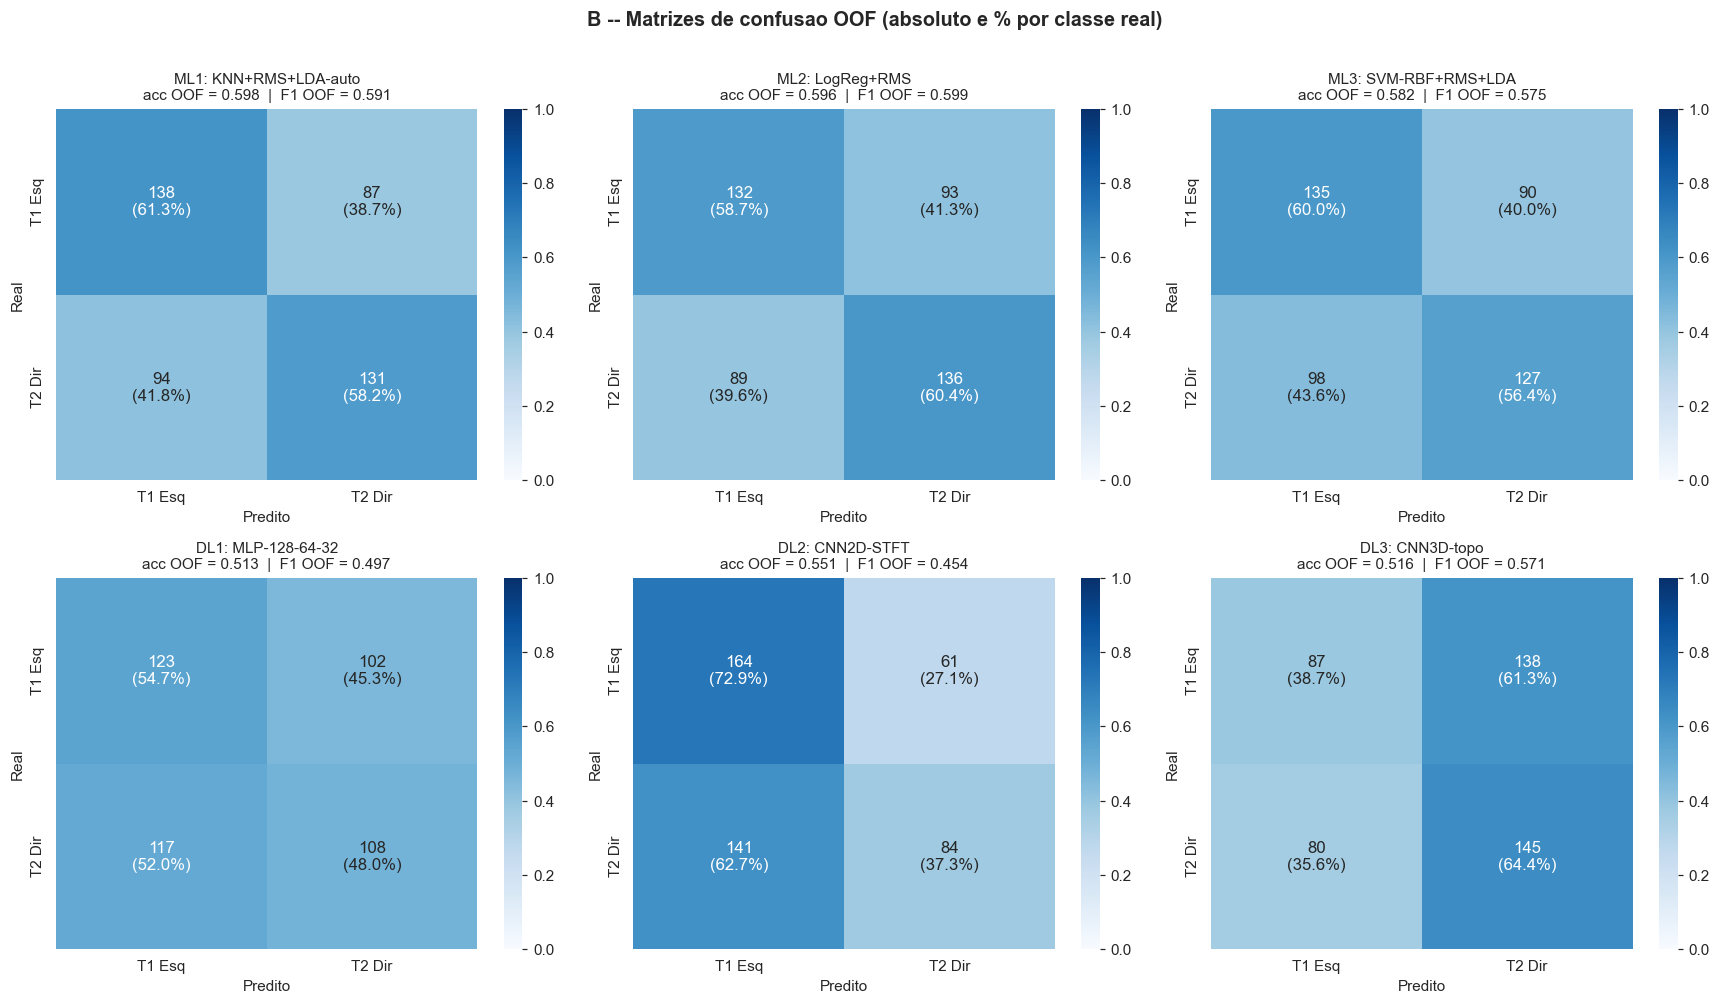

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
class_labels = ['T1 Esq', 'T2 Dir']

for ax, (name, res) in zip(axes, ALL_RESULTS.items()):
    cm   = confusion_matrix(y_arr, np.asarray(res['oof_preds']).ravel(),
                            labels=[label_T1, label_T2])
    cmn  = cm / cm.sum(axis=1, keepdims=True)   # normalizada por linha (recall)
    annot = np.array([[f'{cm[i,j]}\n({100*cmn[i,j]:.1f}%)'
                       for j in range(2)] for i in range(2)])
    sns.heatmap(cmn, annot=annot, fmt='', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels,
                ax=ax, cbar=True, vmin=0, vmax=1,
                annot_kws={'fontsize': 11})
    ax.set_xlabel('Predito'); ax.set_ylabel('Real')
    acc = accuracy_score(y_arr, res['oof_preds'])
    f1v = f1_score(y_arr, res['oof_preds'])
    ax.set_title(f'{name}\nacc OOF = {acc:.3f}  |  F1 OOF = {f1v:.3f}',
                 fontsize=10)

plt.suptitle('(B) Matrizes de confusao OOF (absoluto e % por classe real)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


### B-3) Comparativo direto entre modelos (barras)

Dois painéis:
- **Esquerda:** barra empilhada com TN/FP/FN/TP em % do total.
- **Direita:** recall por classe, lado a lado - diagnóstico de viés de classe.

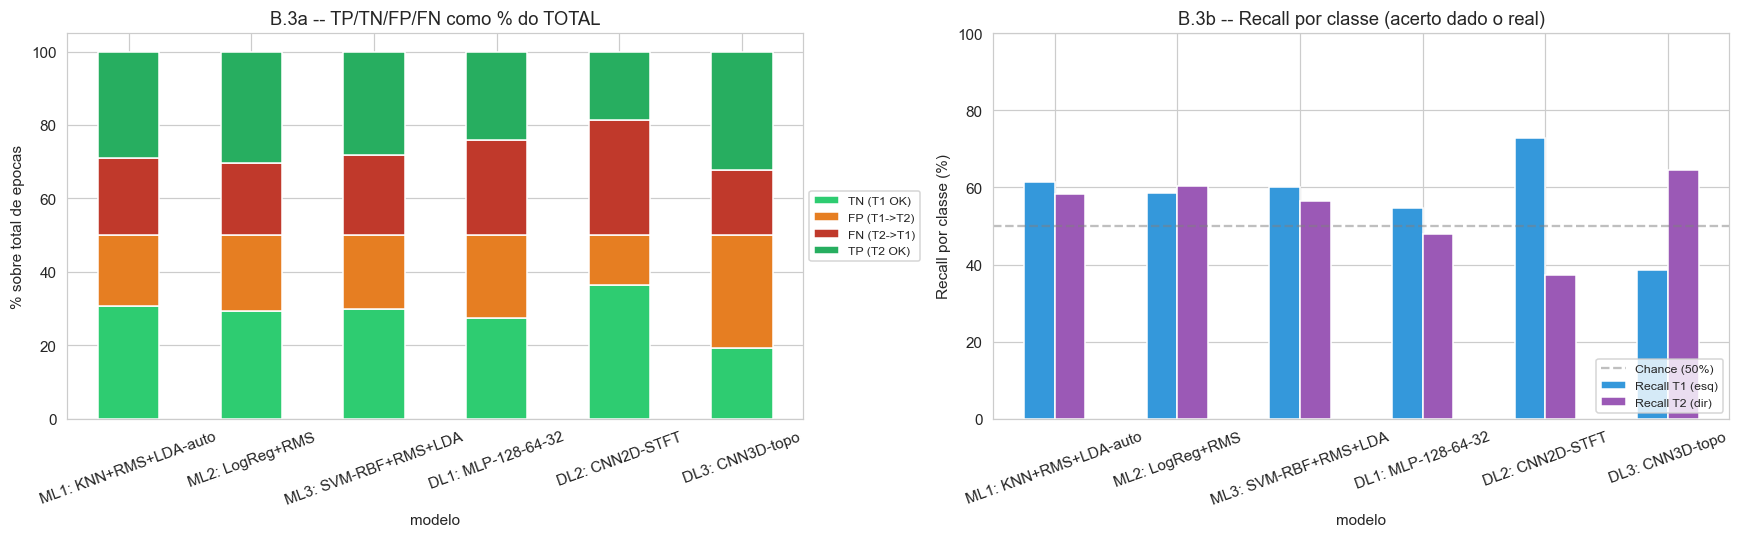

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (1) Barra empilhada - % sobre total
plot_df = CM_DF[['TN_%total', 'FP_%total', 'FN_%total', 'TP_%total']].copy()
plot_df.columns = ['TN (T1 OK)', 'FP (T1->T2)', 'FN (T2->T1)', 'TP (T2 OK)']
plot_df.plot(kind='bar', stacked=True, ax=axes[0],
             color=['#2ECC71', '#E67E22', '#C0392B', '#27AE60'])
axes[0].set_ylabel('% sobre total de epocas')
axes[0].set_title('(B.3a) TP/TN/FP/FN como % do TOTAL')
axes[0].legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
axes[0].tick_params(axis='x', rotation=20)

# (2) Recall por classe (= acerto dado o real)
plot_df2 = CM_DF[['TN_%T1real', 'TP_%T2real']].copy()
plot_df2.columns = ['Recall T1 (esq)', 'Recall T2 (dir)']
plot_df2.plot(kind='bar', ax=axes[1], color=['#3498DB', '#9B59B6'])
axes[1].axhline(50, color='gray', ls='--', alpha=0.5, label='Chance (50%)')
axes[1].set_ylabel('Recall por classe (%)')
axes[1].set_title('(B.3b) Recall por classe (acerto dado o real)')
axes[1].legend(loc='lower right', fontsize=8)
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylim(0, 100)

plt.tight_layout(); plt.show()


## C) Verificação de overfitting / underfitting

### O que é overfit, underfit e como detectá-los?

| Cenário | Acc treino | Acc teste | Gap | Sintoma |
|---------|-----------|----------|-----|---------|
| **Underfit** | baixa (~0.55) | baixa (~0.55) | ≈ 0 | Modelo sem capacidade, não aprendeu |
| **Bom ajuste** | razoável (~0.70) | razoável (~0.65) | pequeno (<0.10) | Generaliza bem |
| **Overfit moderado** | alta (~0.85) | razoável (~0.65) | médio (0.10–0.20) | Memorizou parte do treino |
| **Overfit severo** | ~1.00 | baixa (~0.55) | grande (>0.20) | Decorou, não generaliza |

### Três fontes de evidência usadas aqui

| Subseção | Evidência | O que detecta |
|----------|-----------|---------------|
| **C-1** | Tabela gap = train_acc − test_acc | Magnitude do overfit |
| **C-2** | Barras lado a lado | Visualização rápida do gap |
| **C-3** | Learning curves (acc vs tamanho do treino) | Se mais dados ajudariam ou se o modelo já saturou |
| **C-4** | Loss × época (CNNs) | Overfit dinâmico - gap crescendo com as épocas |
| **C-5** | Boxplots da variância entre folds | Estabilidade - variância alta sugere overfit a folds específicos |

### C-1) Tabela de gap treino-teste e diagnóstico textual

In [16]:
gap_rows = []
for name, res in ALL_RESULTS.items():
    pf = res['per_fold']
    train_acc = pd.to_numeric(pf['train_acc'], errors='coerce')
    test_acc  = pd.to_numeric(pf['test_acc'],  errors='coerce')

    train_mean = train_acc.mean()
    test_mean  = test_acc.mean()
    test_std   = test_acc.std()

    gap_rows.append({
        'modelo':              name,
        'train_acc_media':     train_mean,
        'test_acc_media':      test_mean,
        'gap (treino-teste)':  train_mean - test_mean,
        'std_test_acc':        test_std,
        'cv_test_acc':         test_std / max(test_mean, 1e-9),
    })

GAP_DF = pd.DataFrame(gap_rows).set_index('modelo')
print('=== C.1 -- Gap treino-teste (accuracy) e variancia ===\n')
print(GAP_DF.round(3).to_string())


# Diagnostico textual baseado em regras
def diagnose(gap, test, cv):
    if pd.isna(gap) or pd.isna(test):
        return 'NA'
    if gap > 0.20:
        return 'OVERFITTING SEVERO'
    if gap > 0.10:
        return 'overfit moderado'
    if test < 0.55:
        return 'underfit (proximo do chance)'
    if pd.notna(cv) and cv > 0.20:
        return 'instavel (alta variancia entre folds)'
    return 'OK (gap pequeno e test razoavel)'


print('\n=== C.1.bis -- Diagnostico ===')
for name, row in GAP_DF.iterrows():
    diag = diagnose(row['gap (treino-teste)'], row['test_acc_media'], row['cv_test_acc'])
    print(f'  {name:<28s}  gap={row["gap (treino-teste)"]:+.3f}  '
          f'acc={row["test_acc_media"]:.3f}  -> {diag}')


=== C.1 -- Gap treino-teste (accuracy) e variancia ===

                       train_acc_media  test_acc_media  gap (treino-teste)  std_test_acc  cv_test_acc
modelo                                                                                               
ML1: KNN+RMS+LDA-auto            0.774           0.598               0.176         0.047        0.079
ML2: LogReg+RMS                  0.757           0.596               0.162         0.065        0.109
ML3: SVM-RBF+RMS+LDA             0.770           0.582               0.188         0.038        0.066
DL1: MLP-128-64-32               0.791           0.513               0.278         0.047        0.092
DL2: CNN2D-STFT                  0.626           0.551               0.074         0.054        0.097
DL3: CNN3D-topo                  0.521           0.516               0.006         0.043        0.084

=== C.1.bis -- Diagnostico ===
  ML1: KNN+RMS+LDA-auto         gap=+0.176  acc=0.598  -> overfit moderado
  ML2: LogReg+RMS    

### C-2) Visualização: barras de treino vs. teste

Cada modelo aparece com duas barras (treino azul, teste vermelho) e o gap impresso acima. Quanto maior o gap, mais o modelo memorizou em vez de generalizar.

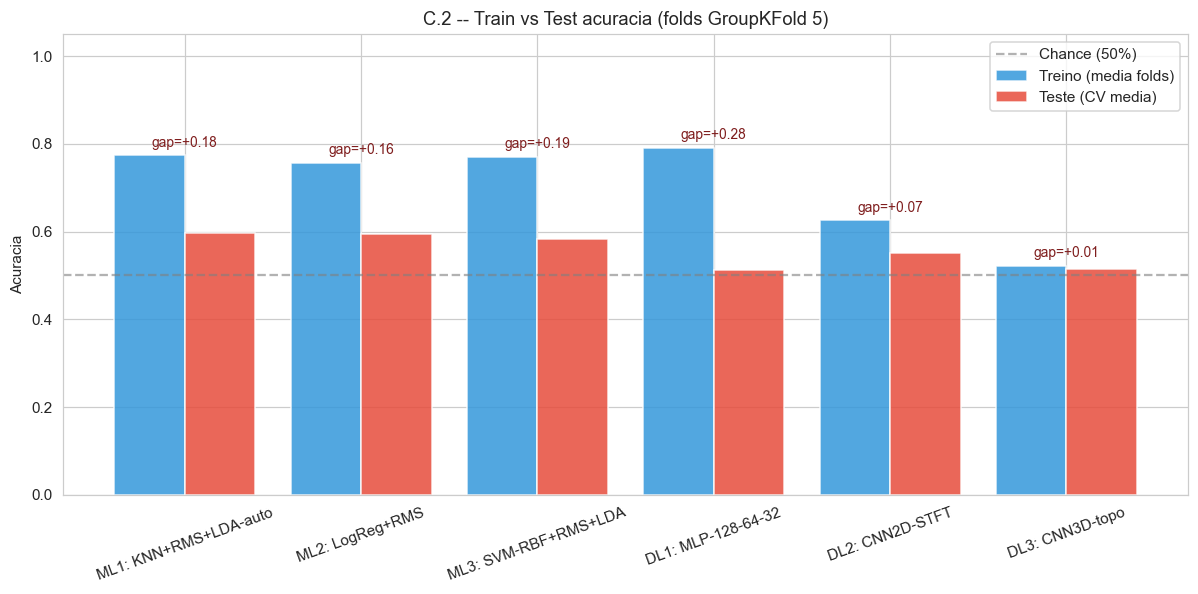

In [17]:
fig, ax = plt.subplots(figsize=(11, 5.5))
xs = np.arange(len(GAP_DF))

ax.bar(xs - 0.2, GAP_DF['train_acc_media'], 0.4,
       label='Treino (media folds)', color='#3498DB', alpha=0.85)
ax.bar(xs + 0.2, GAP_DF['test_acc_media'],  0.4,
       label='Teste (CV media)',     color='#E74C3C', alpha=0.85)

ax.axhline(0.5, color='gray', ls='--', alpha=0.6, label='Chance (50%)')
ax.set_xticks(xs); ax.set_xticklabels(GAP_DF.index, rotation=20)
ax.set_ylabel('Acuracia'); ax.set_ylim(0, 1.05)
ax.set_title('C.2 -- Train vs Test acuracia (folds GroupKFold 5)')
ax.legend()

for i, (tr, te) in enumerate(zip(GAP_DF['train_acc_media'], GAP_DF['test_acc_media'])):
    ax.text(i, max(tr, te) + 0.02, f'gap={tr-te:+.2f}',
            ha='center', fontsize=9, color='#7F1D1D')

plt.tight_layout(); plt.show()


### C-3_ Learning curves (sklearn)

A learning_curv` do sklearn refaz o modelo com frações progressivas dos dados de treino (20%, 40%, 60%, 80%, 100%) e mede acurácia em treino e CV. Diz duas coisas:

1. **Se a curva de teste ainda está subindo** ao chegar em 100% => mais dados ajudariam.
2. **Se as curvas de treino e teste convergiram** => o modelo já está no seu teto, mais dados não ajudam.

Aplicada apenas aos 4 modelos sklearn-compatíveis (3 ML + MLP). As CNNs aparecem na C-4 com loss × época (que carrega informação análoga).

C.3 -- Calculando learning curves dos modelos sklearn...

Carregado do cache.


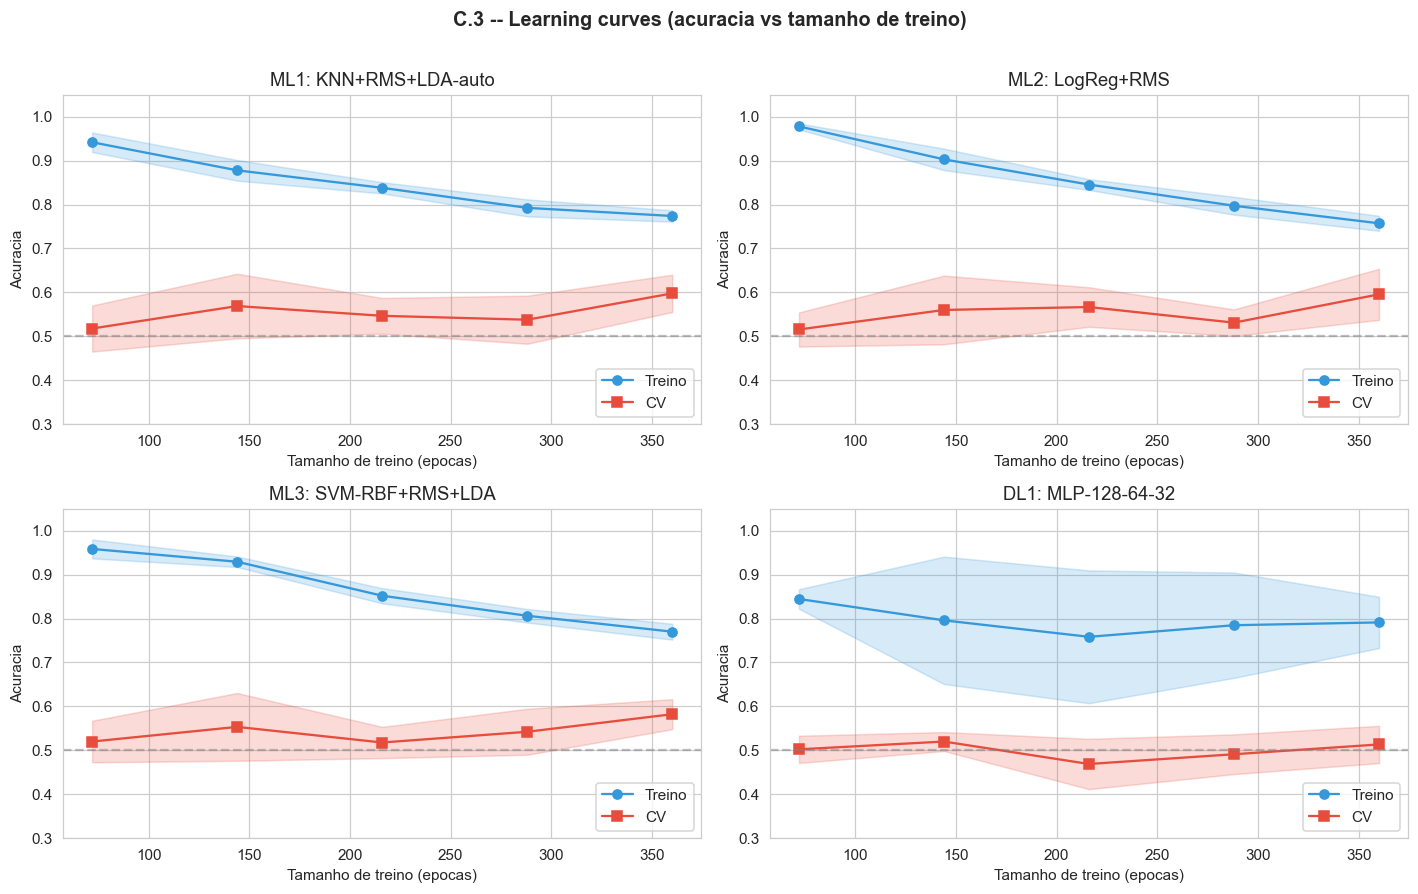

In [ ]:
print('C.3 -- Calculando learning curves dos modelos sklearn...\n')

sklearn_models_lc = {
    'ML1: KNN+RMS+LDA-auto':  (PIPE_ML1, X_feat_rms),
    'ML2: LogReg+RMS':        (PIPE_ML2, X_feat_rms),
    'ML3: SVM-RBF+RMS+LDA':   (PIPE_ML3, X_feat_rms),
    'DL1: MLP-128-64-32':     (PIPE_MLP, X_feat),
}

train_sizes_frac = np.linspace(0.2, 1.0, 5)

if LC_CACHE.exists():
    with open(LC_CACHE, 'rb') as f:
        LEARN_CURVE_DATA = pickle.load(f)
    print('Carregado do cache.')
else:
    LEARN_CURVE_DATA = {}
    for name, (pipe, X_data) in sklearn_models_lc.items():
        print(f'  ... {name}')
        try:
            ts, tr_sc, te_sc = learning_curve(
                _fix_pipeline_for_cv(pipe),
                np.asarray(X_data),
                np.asarray(y).ravel(),
                groups=np.asarray(groups).ravel(),
                cv=GroupKFold(n_splits=5),
                train_sizes=train_sizes_frac,
                scoring='accuracy',
                n_jobs=1,
                shuffle=False,
                error_score=np.nan,
            )
            LEARN_CURVE_DATA[name] = {'sizes': ts, 'tr': tr_sc, 'te': te_sc}
        except Exception as e:
            print(f'    AVISO falhou: {e}')
            LEARN_CURVE_DATA[name] = None

    with open(LC_CACHE, 'wb') as f:
        pickle.dump(LEARN_CURVE_DATA, f)


# Plot
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, (name, d) in zip(axes, LEARN_CURVE_DATA.items()):
    if d is None:
        ax.set_title(f'{name}\n(falhou)'); ax.axis('off'); continue

    ts = d['sizes']
    tr_m, tr_s = np.nanmean(d['tr'], axis=1), np.nanstd(d['tr'], axis=1)
    te_m, te_s = np.nanmean(d['te'], axis=1), np.nanstd(d['te'], axis=1)

    ax.plot(ts, tr_m, 'o-', color='#3498DB', label='Treino')
    ax.fill_between(ts, tr_m - tr_s, tr_m + tr_s, alpha=0.2, color='#3498DB')
    ax.plot(ts, te_m, 's-', color='#E74C3C', label='CV')
    ax.fill_between(ts, te_m - te_s, te_m + te_s, alpha=0.2, color='#E74C3C')

    ax.axhline(0.5, color='gray', ls='--', alpha=0.5)
    ax.set_xlabel('Tamanho de treino (epocas)'); ax.set_ylabel('Acuracia')
    ax.set_ylim(0.3, 1.05); ax.set_title(name); ax.legend(loc='lower right')

plt.suptitle('(C.3) Learning curves (acuracia vs tamanho de treino)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


### C-4) Loss e accuracy × época (CNNs)

Para as duas CNNs, mostramos as curvas de cada um dos 5 folds (linhas finas) e a média (linha grossa):
- **Loss vs época:** se a train_loss cai mas a val_loss para de cair (ou sobe) => overfit dinâmico.
- **Accuracy vs época:** sintoma análogo.

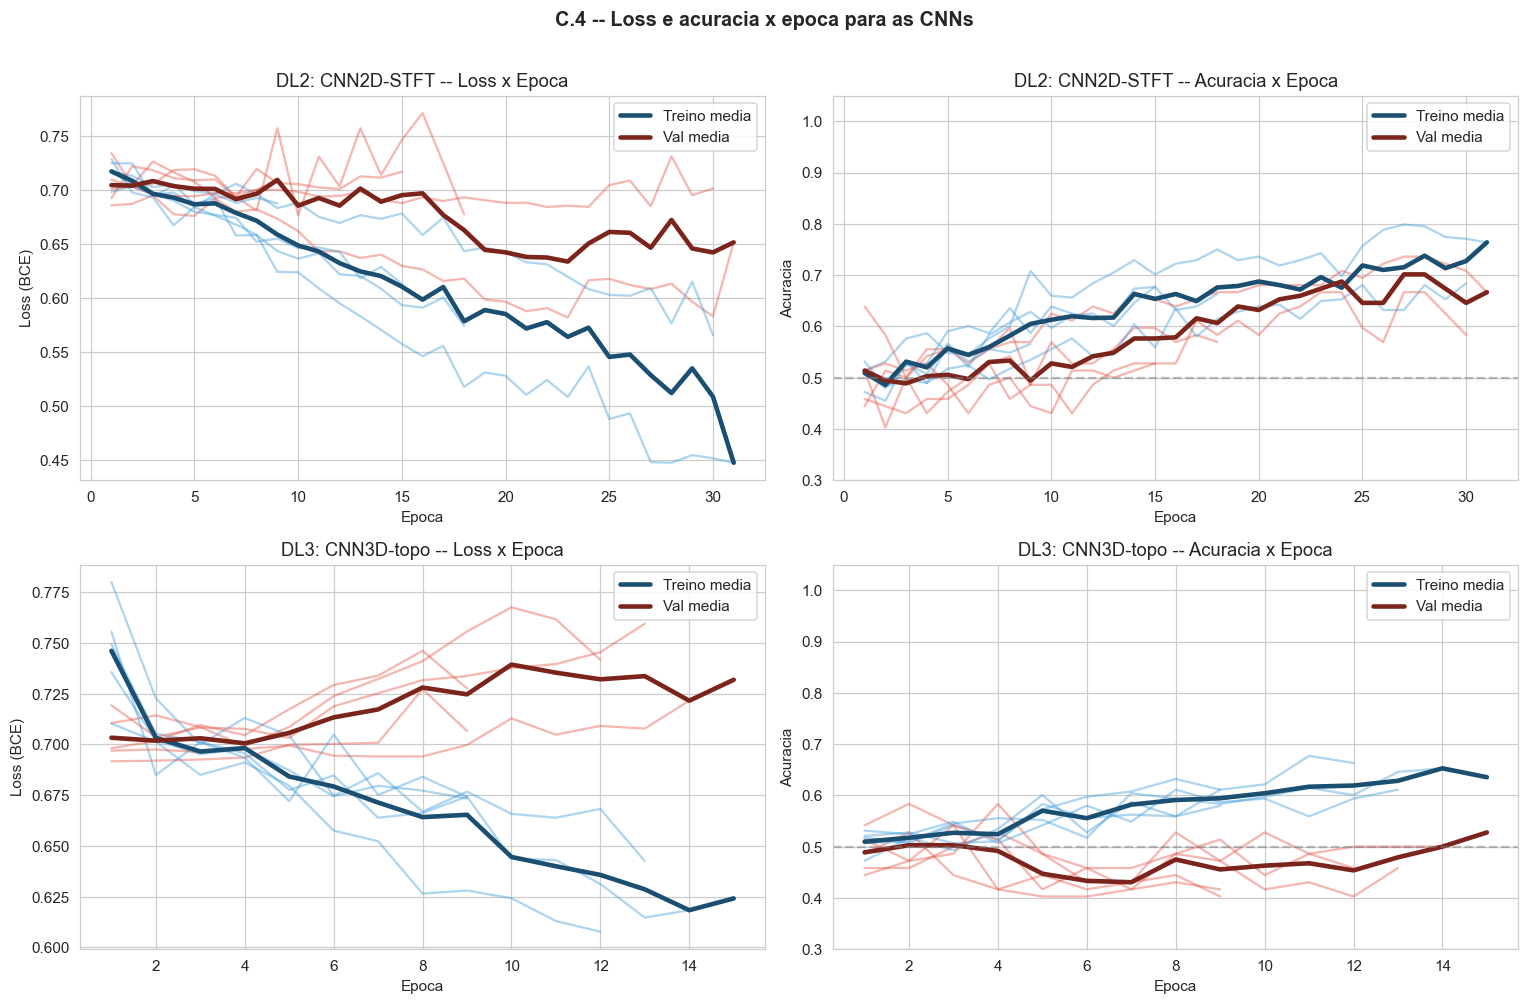

In [ ]:
if HAS_KERAS and 'DL2: CNN2D-STFT' in ALL_RESULTS:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    cnns = [('DL2: CNN2D-STFT', axes[0]),
            ('DL3: CNN3D-topo', axes[1])]

    for name, ax_row in cnns:
        if name not in ALL_RESULTS or 'histories' not in ALL_RESULTS[name]:
            continue
        hs = ALL_RESULTS[name]['histories']
        max_len = max(len(h['loss']) for h in hs)

        #  Loss 
        m_tr = np.full((len(hs), max_len), np.nan)
        m_va = np.full((len(hs), max_len), np.nan)
        for k, h in enumerate(hs):
            m_tr[k, :len(h['loss'])] = h['loss']
            if 'val_loss' in h:
                m_va[k, :len(h['val_loss'])] = h['val_loss']
            ax_row[0].plot(np.arange(1, len(h['loss']) + 1),
                           h['loss'], color='#3498DB', alpha=0.4)
            if 'val_loss' in h:
                ax_row[0].plot(np.arange(1, len(h['val_loss']) + 1),
                               h['val_loss'], color='#E74C3C', alpha=0.4)
        ax_row[0].plot(np.arange(1, max_len+1), np.nanmean(m_tr, axis=0),
                       lw=3, color='#1B4F72', label='Treino media')
        ax_row[0].plot(np.arange(1, max_len+1), np.nanmean(m_va, axis=0),
                       lw=3, color='#7B241C', label='Val media')
        ax_row[0].set_xlabel('Epoca'); ax_row[0].set_ylabel('Loss (BCE)')
        ax_row[0].set_title(f'{name} -- Loss x Epoca'); ax_row[0].legend()

        #  Accuracy 
        m_tra = np.full((len(hs), max_len), np.nan)
        m_vaa = np.full((len(hs), max_len), np.nan)
        for k, h in enumerate(hs):
            m_tra[k, :len(h['accuracy'])] = h['accuracy']
            if 'val_accuracy' in h:
                m_vaa[k, :len(h['val_accuracy'])] = h['val_accuracy']
            ax_row[1].plot(np.arange(1, len(h['accuracy']) + 1),
                           h['accuracy'], color='#3498DB', alpha=0.4)
            if 'val_accuracy' in h:
                ax_row[1].plot(np.arange(1, len(h['val_accuracy']) + 1),
                               h['val_accuracy'], color='#E74C3C', alpha=0.4)
        ax_row[1].plot(np.arange(1, max_len+1), np.nanmean(m_tra, axis=0),
                       lw=3, color='#1B4F72', label='Treino media')
        ax_row[1].plot(np.arange(1, max_len+1), np.nanmean(m_vaa, axis=0),
                       lw=3, color='#7B241C', label='Val media')
        ax_row[1].axhline(0.5, color='gray', ls='--', alpha=0.5)
        ax_row[1].set_xlabel('Epoca'); ax_row[1].set_ylabel('Acuracia')
        ax_row[1].set_title(f'{name} -- Acuracia x Epoca')
        ax_row[1].legend(); ax_row[1].set_ylim(0.3, 1.05)

    plt.suptitle('(C.4) Loss e acuracia x epoca para as CNNs',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()
else:
    print('CNNs nao disponiveis -- pulando C.4.')


### C-5) Variância entre folds (boxplots)

Cada box-plot mostra a distribuição de uma métrica (5 valores, um por fold). Caixas estreitas = modelo estável; caixas largas = sensível a quais sujeitos caem em qual fold.

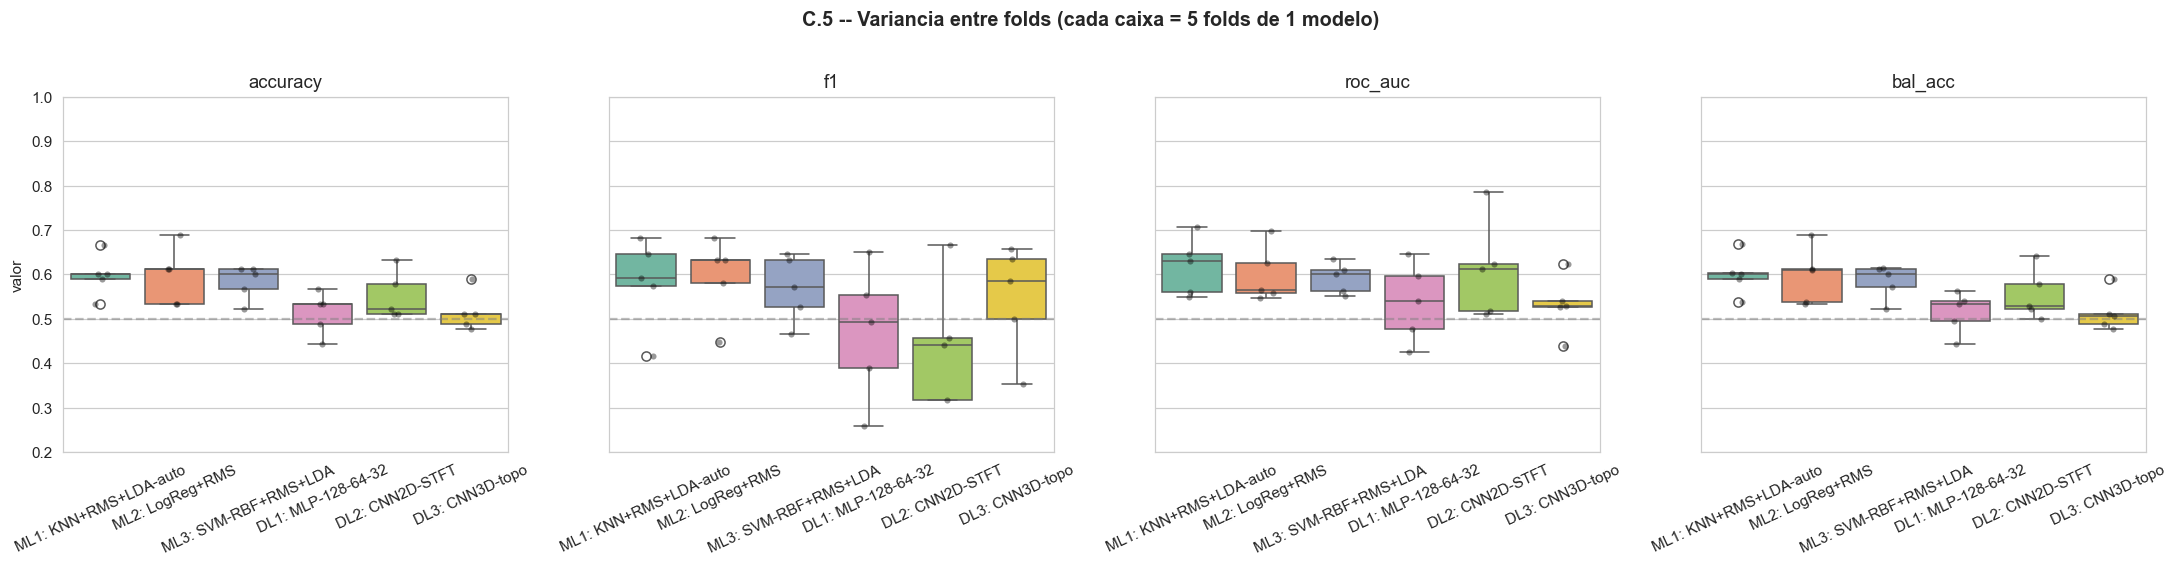

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for ax, met in zip(axes, ['accuracy', 'f1', 'roc_auc', 'bal_acc']):
    sub = LONG[LONG['metric'] == met]
    sns.boxplot(data=sub, x='modelo', y='value', ax=ax, palette='Set2')
    sns.stripplot(data=sub, x='modelo', y='value', ax=ax,
                  color='black', alpha=0.4, size=4)
    ax.axhline(0.5, color='gray', ls='--', alpha=0.5)
    ax.set_title(met); ax.set_xlabel(''); ax.set_ylabel('valor')
    ax.tick_params(axis='x', rotation=25); ax.set_ylim(0.2, 1.0)

plt.suptitle('(C.5) Variancia entre folds (cada caixa = 5 folds de 1 modelo)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


## D) Testes de normalidade

### Por que testar normalidade?

O teste de Tukey HSD (que usaremos na seção G) pressupõe que os resíduos são aproximadamente normais e que as variâncias dos grupos são homogêneas. Se nenhuma dessas condições é satisfeita, devemos preferir alternativas não-paramétricas (Friedman + Nemenyi, ou Wilcoxon pareado).

### Os 4 testes aplicados

| Teste | Hipótese H₀ | Boa para |
|-------|-------------|----------|
| **Shapiro-Wilk** | Os dados vêm de uma distribuição normal | n pequeno (5–50) - ideal aqui|
| **D'Agostino-Pearson (normaltest)** | Idem | n ≥ 8 - combina assimetria + curtose |
| **Anderson-Darling** | Idem | Sensível a desvios nas caudas |
| **Kolmogorov-Smirnov** | A distribuição empírica = N(μ̂, σ̂) | n grande - conservador para n pequeno |

### Aplicação em duas escalas

| Subseção | Escala | n | Comentário |
|----------|--------|---|------------|
| **D-1** | Global por métrica (todos os folds, todos os modelos) | 30 | n confortável para Shapiro |
| **D-2** | Por modelo, em accuracy | 5 | n baixo - Shapiro tem pouca potência, raramente rejeita |

### Como interpretar

- **p > 0.05** => não rejeitamos H₀ => assumimos normalidade.
- **p < 0.05** => rejeitamos H₀ => recorrer a testes não-paramétricos.

### D-1) Normalidade global

In [ ]:
def normality_panel(values, alpha=0.05):
    """Aplica varios testes de normalidade e retorna um dict."""
    out = {'n': len(values), 'mean': np.mean(values), 'std': np.std(values, ddof=1)}

    # Shapiro-Wilk (n>=3)
    if len(values) >= 3:
        try:
            sw_stat, sw_p = shapiro(values)
            out['shapiro_W'] = sw_stat
            out['shapiro_p'] = sw_p
        except Exception:
            out['shapiro_W'] = np.nan; out['shapiro_p'] = np.nan

    # D'Agostino-Pearson (n>=8)
    if len(values) >= 8:
        try:
            k2, p_k2 = normaltest(values)
            out['dagostino_K2'] = k2
            out['dagostino_p']  = p_k2
        except Exception:
            out['dagostino_K2'] = np.nan; out['dagostino_p'] = np.nan
    else:
        out['dagostino_K2'] = np.nan; out['dagostino_p'] = np.nan

    # Anderson-Darling
    if len(values) >= 4:
        try:
            ad = anderson(values, dist='norm')
            out['anderson_A2'] = ad.statistic
            out['anderson_critical_5%'] = ad.critical_values[2]   # nivel 5%
            out['anderson_normal'] = bool(ad.statistic < ad.critical_values[2])
        except Exception:
            out['anderson_A2'] = np.nan

    # KS contra N(mu, sd) estimada
    if len(values) >= 4:
        try:
            mu, sd = np.mean(values), np.std(values, ddof=1)
            ks_stat, ks_p = kstest(values, 'norm', args=(mu, sd))
            out['ks_stat'] = ks_stat; out['ks_p'] = ks_p
        except Exception:
            out['ks_stat'] = np.nan; out['ks_p'] = np.nan

    out['veredito_shapiro']   = ('NORMAL' if out.get('shapiro_p', 0) > alpha
                                  else 'NAO normal')
    out['veredito_dagostino'] = ('NORMAL' if out.get('dagostino_p', 0) > alpha
                                  else 'NAO normal') if not np.isnan(out.get('dagostino_p', np.nan)) else '-'
    return out


print('=== (D.1) Normalidade GLOBAL por metrica (n=30 = 6 modelos x 5 folds) ===\n')
global_rows = []
for met in ['accuracy', 'f1', 'roc_auc', 'bal_acc']:
    vals  = LONG[LONG['metric'] == met]['value'].values
    panel = normality_panel(vals)
    panel['name'] = met
    global_rows.append(panel)

GLOBAL_NORMAL = pd.DataFrame(global_rows).set_index('name')
print(GLOBAL_NORMAL.round(4).to_string())


=== D.1 -- Normalidade GLOBAL por metrica (n=30 = 6 modelos x 5 folds) ===

           n    mean     std  shapiro_W  shapiro_p  dagostino_K2  dagostino_p  anderson_A2  anderson_critical_5%  anderson_normal  ks_stat    ks_p veredito_shapiro veredito_dagostino
name                                                                                                                                                                                  
accuracy  30  0.5593  0.0578     0.9684     0.4959        0.4570       0.7957       0.4856                 0.732             True   0.1731  0.2944           NORMAL             NORMAL
f1        30  0.5242  0.1465     0.8692     0.0016       14.2823       0.0008       1.0633                 0.732            False   0.1598  0.3869       NAO normal         NAO normal
roc_auc   30  0.5811  0.0766     0.9722     0.6013        1.9014       0.3865       0.3561                 0.732             True   0.1180  0.7538           NORMAL             NORMAL
bal_acc  

### D-2) Normalidade por modelo 

Com apenas 5 valores por grupo, Shapiro-Wilk tem baixa potência estatística, raramente rejeita H₀. Isso é uma limitação do dataset, não uma falha do teste. Reportamos para checar se algum modelo apresenta um desvio gritante.

In [ ]:
print('=== (D.2) Normalidade POR MODELO em accuracy (n=5) ===\n')
per_model_rows = []
for name, res in ALL_RESULTS.items():
    panel = normality_panel(res['per_fold']['test_acc'].values)
    panel['name'] = name
    per_model_rows.append(panel)

PERMODEL_NORMAL = pd.DataFrame(per_model_rows).set_index('name')
print(PERMODEL_NORMAL[['n', 'mean', 'std', 'shapiro_W', 'shapiro_p',
                       'veredito_shapiro']].round(4).to_string())


# Veredito condensado por (modelo x metrica)
print('\n=== (D.2.bis) Veredito Shapiro por (modelo x metrica) ===\n')
ver_rows = []
for name, res in ALL_RESULTS.items():
    row = {'modelo': name}
    for col, lab in [('test_acc', 'accuracy'), ('test_f1', 'f1'),
                     ('test_auc', 'roc_auc'), ('test_bal_acc', 'bal_acc')]:
        v = res['per_fold'][col].values
        try:
            _, p = shapiro(v)
            row[lab + '_p']  = p
            row[lab + '_OK'] = 'NORMAL' if p > 0.05 else 'NAO'
        except Exception:
            row[lab + '_p']  = np.nan
            row[lab + '_OK'] = '-'
    ver_rows.append(row)

VER_DF = pd.DataFrame(ver_rows).set_index('modelo')
print(VER_DF.round(3).to_string())


=== D.2 -- Normalidade POR MODELO em accuracy (n=5) ===

                       n    mean     std  shapiro_W  shapiro_p veredito_shapiro
name                                                                           
ML1: KNN+RMS+LDA-auto  5  0.5978  0.0474     0.9275     0.5792           NORMAL
ML2: LogReg+RMS        5  0.5956  0.0651     0.8810     0.3140           NORMAL
ML3: SVM-RBF+RMS+LDA   5  0.5822  0.0382     0.8362     0.1548           NORMAL
DL1: MLP-128-64-32     5  0.5133  0.0474     0.9409     0.6725           NORMAL
DL2: CNN2D-STFT        5  0.5511  0.0536     0.8232     0.1236           NORMAL
DL3: CNN3D-topo        5  0.5156  0.0435     0.8305     0.1402           NORMAL

=== D.2.bis -- Veredito Shapiro por (modelo x metrica) ===

                       accuracy_p accuracy_OK   f1_p   f1_OK  roc_auc_p roc_auc_OK  bal_acc_p bal_acc_OK
modelo                                                                                                  
ML1: KNN+RMS+LDA-auto       0.57

## E) Estatísticas descritivas das principais métricas

describe() gera 8 estatísticas por modelo×métrica: contagem, média, desvio, mínimo, 1º quartil, mediana, 3º quartil, máximo. É o resumo numérico mais completo possível para n pequeno.

### Por que olhar mediana e quartis (não só média)?

Com 5 folds, um único fold ruim pode arrastar a média. A mediana é boa contra outliers, comparando mean e 50% (mediana) sinaliza se há fold(s) atípico(s). Se mean ≪ 50%, há um fold puxando a média para baixo.

In [ ]:
print('=== (E.1) describe() por modelo (5 folds por celula) ===\n')

for met_col, met_lab in [('test_acc',     'ACCURACY'),
                          ('test_f1',      'F1'),
                          ('test_auc',     'ROC_AUC'),
                          ('test_bal_acc', 'BALANCED_ACC'),
                          ('test_prec',    'PRECISION'),
                          ('test_rec',     'RECALL')]:
    print(f'\n----------  {met_lab}  ----------')
    rows = {name: res['per_fold'][met_col].values for name, res in ALL_RESULTS.items()}
    df_m = pd.DataFrame(rows)
    print(df_m.describe().T.round(3).to_string())


=== E.1 -- describe() por modelo (5 folds por celula) ===


----------  ACCURACY  ----------
                       count   mean    std    min    25%    50%    75%    max
ML1: KNN+RMS+LDA-auto    5.0  0.598  0.047  0.533  0.589  0.600  0.600  0.667
ML2: LogReg+RMS          5.0  0.596  0.065  0.533  0.533  0.611  0.611  0.689
ML3: SVM-RBF+RMS+LDA     5.0  0.582  0.038  0.522  0.567  0.600  0.611  0.611
DL1: MLP-128-64-32       5.0  0.513  0.047  0.444  0.489  0.533  0.533  0.567
DL2: CNN2D-STFT          5.0  0.551  0.054  0.511  0.511  0.522  0.578  0.633
DL3: CNN3D-topo          5.0  0.516  0.043  0.478  0.489  0.511  0.511  0.589

----------  F1  ----------
                       count   mean    std    min    25%    50%    75%    max
ML1: KNN+RMS+LDA-auto    5.0  0.582  0.102  0.417  0.575  0.591  0.647  0.681
ML2: LogReg+RMS          5.0  0.594  0.090  0.447  0.580  0.632  0.632  0.682
ML3: SVM-RBF+RMS+LDA     5.0  0.569  0.075  0.466  0.527  0.571  0.632  0.646
DL1: MLP-128-64-32   

### E-2) Heatmap consolidado das médias

Visualização de todas as métricas-médias dos 6 modelos. Verde = melhor; vermelho = pior.

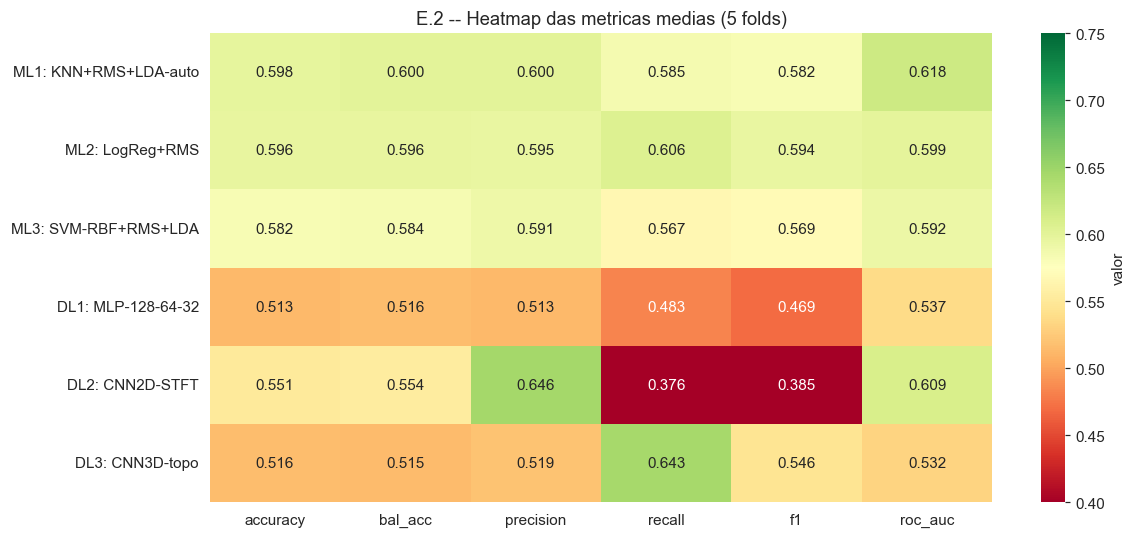

In [ ]:
heat = pd.DataFrame({
    name: {
        'accuracy':  res['per_fold']['test_acc'].mean(),
        'bal_acc':   res['per_fold']['test_bal_acc'].mean(),
        'precision': res['per_fold']['test_prec'].mean(),
        'recall':    res['per_fold']['test_rec'].mean(),
        'f1':        res['per_fold']['test_f1'].mean(),
        'roc_auc':   res['per_fold']['test_auc'].mean(),
    } for name, res in ALL_RESULTS.items()
}).T

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(heat, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.4, vmax=0.75, cbar_kws={'label': 'valor'}, ax=ax)
ax.set_title('(E.2) Heatmap das metricas medias (5 folds)')
plt.tight_layout(); plt.show()


## F) Verificação visual de normalidade

Os testes da seção D são objetivos, mas sofrem de baixa potência com n=5. Inspeção visual complementar: um Q-Q plot mostra com clareza se há cauda pesada, assimetria, ou outliers que os testes podem não pegar.

### Como ler um Q-Q plot

- **Pontos sobre a reta diagonal:** distribuição é aproximadamente normal.
- **Curvatura em "S":** assimetria.
- **Curvatura nas pontas (mas reta no meio):** caudas pesadas (kurtose alta).
- **Pontos aleatórios fora da reta:** distribuição muito diferente da normal.

**Histograma + Q-Q por modelo (F-1) e global por métrica (F-2)**

### F-1) Histograma e Q-Q plot por modelo (em accuracy, n=5)

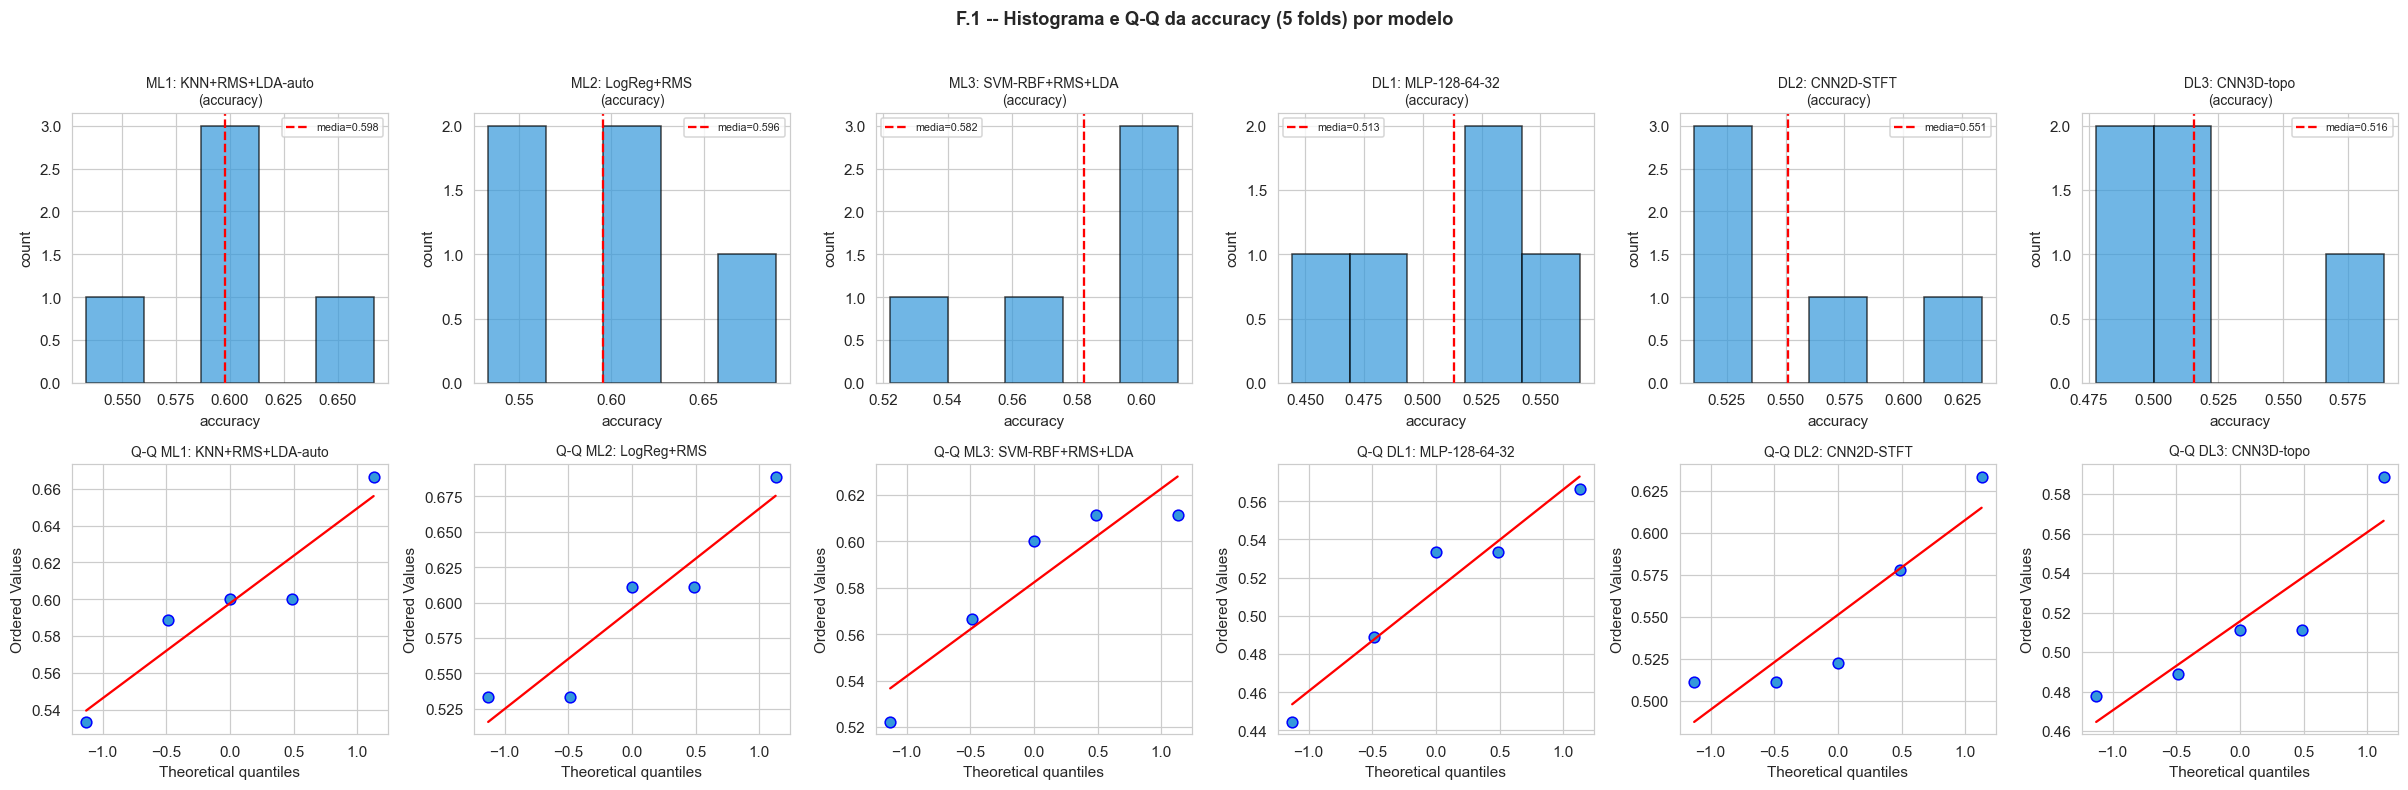

In [ ]:
fig, axes = plt.subplots(2, 6, figsize=(22, 7))

for j, (name, res) in enumerate(ALL_RESULTS.items()):
    v = res['per_fold']['test_acc'].values

    # Histograma
    axes[0, j].hist(v, bins=5, color='#3498DB', alpha=0.7, edgecolor='black')
    axes[0, j].axvline(np.mean(v), color='red', ls='--',
                       label=f'media={np.mean(v):.3f}')
    axes[0, j].set_title(f'{name}\n(accuracy)', fontsize=9)
    axes[0, j].set_xlabel('accuracy'); axes[0, j].set_ylabel('count')
    axes[0, j].legend(fontsize=7)

    # Q-Q
    probplot(v, dist='norm', plot=axes[1, j])
    axes[1, j].set_title(f'Q-Q {name}', fontsize=9)
    axes[1, j].get_lines()[0].set_markerfacecolor('#3498DB')
    axes[1, j].get_lines()[0].set_markersize(7)

plt.suptitle('(F.1) Histograma e Q-Q da accuracy (5 folds) por modelo',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


### F-2) Distribuição global (n=30 por métrica)

Aqui temos potência adequada para julgar visualmente se as métricas têm distribuição aproximadamente normal.

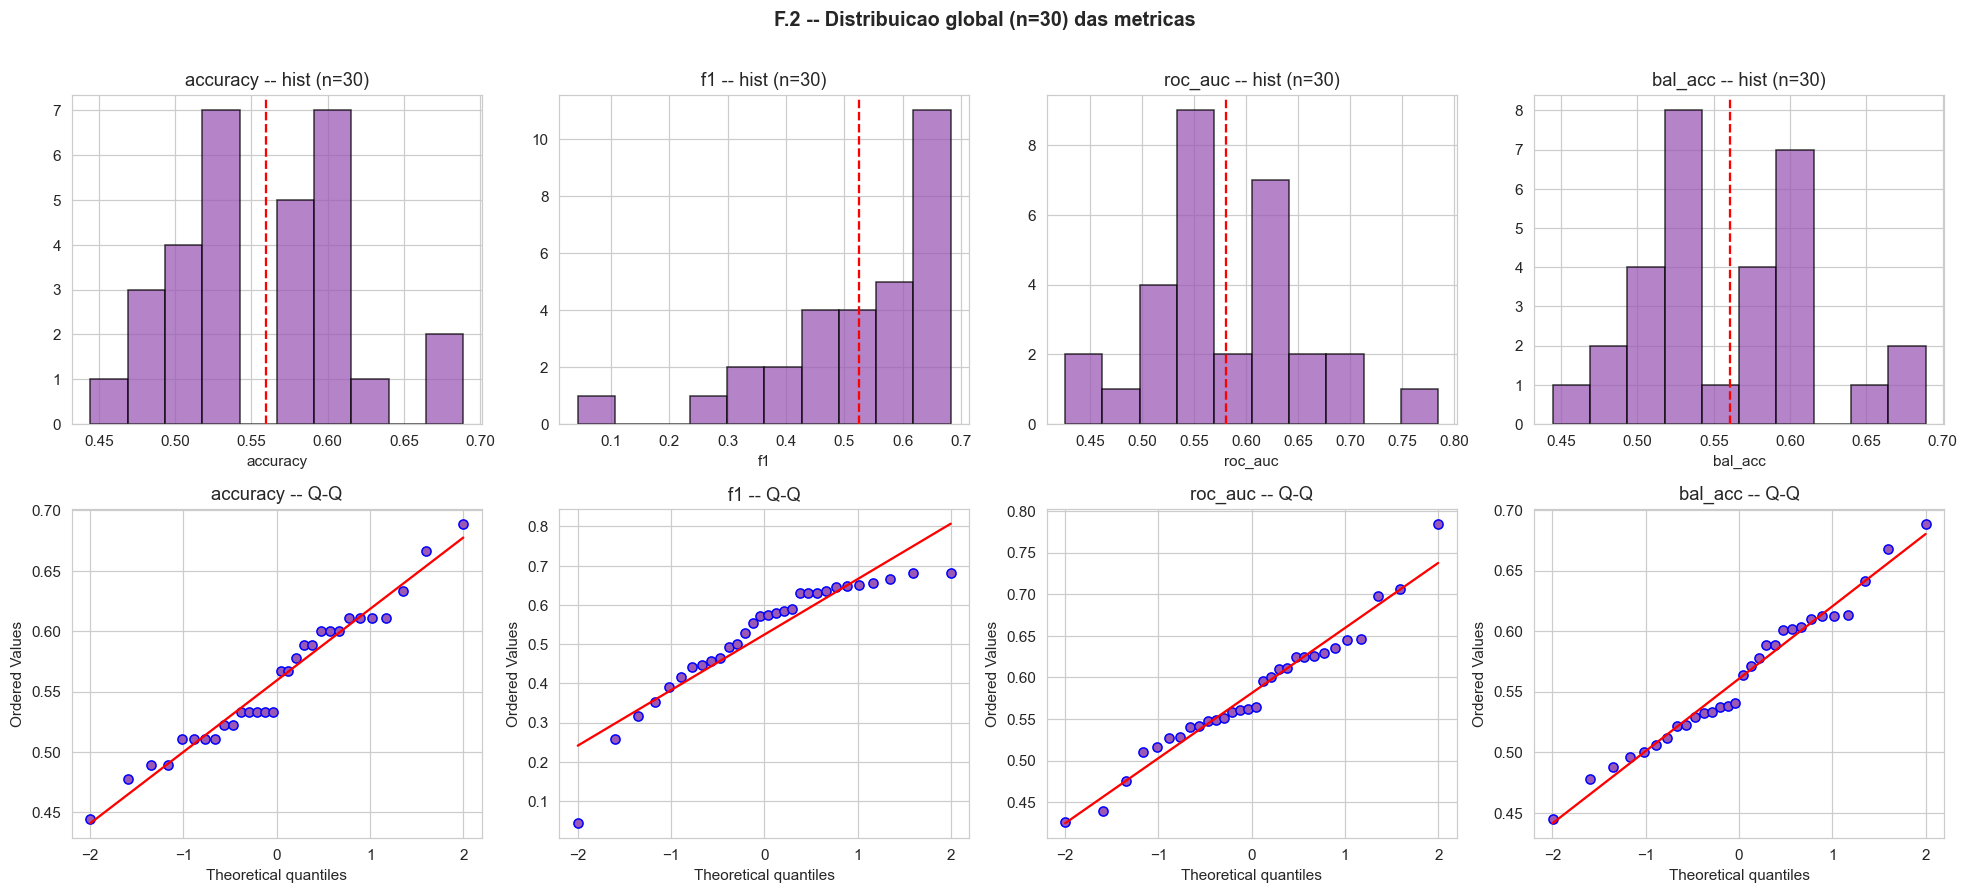

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax_row, dataset_label in zip(axes, ['hist', 'qq']):
    for j, met in enumerate(['accuracy', 'f1', 'roc_auc', 'bal_acc']):
        v = LONG[LONG['metric'] == met]['value'].values
        if dataset_label == 'hist':
            ax_row[j].hist(v, bins=10, color='#9B59B6', alpha=0.75, edgecolor='black')
            ax_row[j].axvline(np.mean(v), color='red', ls='--')
            ax_row[j].set_title(f'{met} -- hist (n={len(v)})')
            ax_row[j].set_xlabel(met)
        else:
            probplot(v, dist='norm', plot=ax_row[j])
            ax_row[j].set_title(f'{met} -- Q-Q')
            ax_row[j].get_lines()[0].set_markerfacecolor('#9B59B6')

plt.suptitle('(F.2) Distribuicao global (n=30) das metricas',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


## G) Comparação estatística entre os 6 modelos

### Hierarquia dos testes aplicados

| Teste | Tipo | Pressuposto | Quando usar |
|-------|------|-------------|-------------|
| **Levene** | Homocedasticidade | — | Verificar pressuposto do Tukey |
| **ANOVA one-way** | Paramétrico, omnibus | Normalidade + homocedasticidade | Há alguma diferença entre modelos? |
| **Tukey HSD** | Paramétrico, par-a-par | Normalidade + homocedasticidade | Quais pares específicos diferem? |
| **Friedman** | Não-paramétrico, omnibus, medidas repetidas | Mesmos folds avaliados em todos os modelos | Há diferença? |
| **Nemenyi** | Não-paramétrico, par-a-par | — | Post-hoc do Friedman |
| **Wilcoxon pareado** | Não-paramétrico, par-a-par | — | Comparar dois modelos (n=5 folds pareados) |

### Por que reportar TODOS?

- O Tukey é clássico.
- O Friedman é mais apropriado para CV pareada (cada fold é uma "réplica" comum aos 6 modelos).
- O Wilcoxon é o teste pareado mais simples, útil para comparações específicas.

Usar todos juntos cria convergência de evidência: se Tukey, Nemenyi e Wilcoxon concordam, a conclusão é forte.

### G-1) Levene + ANOVA + Tukey HSD na accuracy

In [ ]:
# Long-form em accuracy
data_for_anova = []
for name, res in ALL_RESULTS.items():
    for v in res['per_fold']['test_acc'].values:
        data_for_anova.append({'modelo': name, 'accuracy': v})
ANOVA_DF = pd.DataFrame(data_for_anova)


# (a) Levene - homocedasticidade
groups_acc = [res['per_fold']['test_acc'].values for res in ALL_RESULTS.values()]
lev_W, lev_p = levene(*groups_acc)
print('=== (G.1) Teste de Levene (homocedasticidade) ===')
print(f'  W = {lev_W:.3f}, p = {lev_p:.3f}  ->  '
      f'{"variancias homogeneas" if lev_p > 0.05 else "VARIANCIAS DIFERENTES (cuidado)"}\n')


# (b) ANOVA one-way
F, p_anova = f_oneway(*groups_acc)
print('=== (G.1.1) ANOVA one-way ===')
print(f'  F = {F:.3f}, p = {p_anova:.4f}  ->  '
      f'{"REJEITA H0 (medias diferem)" if p_anova < 0.05 else "NAO rejeita H0"}\n')


# (c) Tukey HSD
print('=== (G.1.2) Tukey HSD na accuracy ===\n')
tukey = pairwise_tukeyhsd(endog=ANOVA_DF['accuracy'],
                           groups=ANOVA_DF['modelo'], alpha=0.05)
print(tukey.summary())


=== G.1.0 -- Teste de Levene (homocedasticidade) ===
  W = 0.216, p = 0.952  ->  variancias homogeneas

=== G.1.1 -- ANOVA one-way ===
  F = 2.975, p = 0.0315  ->  REJEITA H0 (medias diferem)

=== G.1.2 -- Tukey HSD na accuracy ===

               Multiple Comparison of Means - Tukey HSD, FWER=0.05               
        group1                group2        meandiff p-adj   lower  upper  reject
---------------------------------------------------------------------------------
   DL1: MLP-128-64-32       DL2: CNN2D-STFT   0.0378 0.8341 -0.0598 0.1354  False
   DL1: MLP-128-64-32       DL3: CNN3D-topo   0.0022    1.0 -0.0954 0.0998  False
   DL1: MLP-128-64-32 ML1: KNN+RMS+LDA-auto   0.0844 0.1177 -0.0132 0.1821  False
   DL1: MLP-128-64-32       ML2: LogReg+RMS   0.0822 0.1348 -0.0154 0.1798  False
   DL1: MLP-128-64-32  ML3: SVM-RBF+RMS+LDA   0.0689 0.2822 -0.0287 0.1665  False
      DL2: CNN2D-STFT       DL3: CNN3D-topo  -0.0356 0.8657 -0.1332 0.0621  False
      DL2: CNN2D-STFT ML1: KN

### G-2) Tukey HSD em F1, AUC e balanced_accuracy

Estendemos o Tukey para as outras métricas-chave. ANOVA pode rejeitar H₀ em uma e não em outra (sensibilidade a outliers de cada métrica).

In [ ]:
def run_tukey_for_metric(metric_col, metric_label):
    rows = []
    for name, res in ALL_RESULTS.items():
        for v in res['per_fold'][metric_col].values:
            rows.append({'modelo': name, metric_label: v})
    df_m = pd.DataFrame(rows)

    g = [res['per_fold'][metric_col].values for res in ALL_RESULTS.values()]
    F, p = f_oneway(*g)
    print(f'\n--- {metric_label.upper()} ---')
    print(f'ANOVA: F = {F:.3f}, p = {p:.4f}')

    tk = pairwise_tukeyhsd(endog=df_m[metric_label],
                            groups=df_m['modelo'], alpha=0.05)
    print(tk.summary())
    return tk


print('=== (G.2) Tukey HSD em outras metricas ===')
for col, lab in [('test_f1', 'f1'), ('test_auc', 'roc_auc'),
                  ('test_bal_acc', 'bal_acc')]:
    _ = run_tukey_for_metric(col, lab)


=== G.2 -- Tukey HSD em outras metricas ===

--- F1 ---
ANOVA: F = 1.739, p = 0.1641
               Multiple Comparison of Means - Tukey HSD, FWER=0.05               
        group1                group2        meandiff p-adj   lower  upper  reject
---------------------------------------------------------------------------------
   DL1: MLP-128-64-32       DL2: CNN2D-STFT  -0.0839 0.9256 -0.3538  0.186  False
   DL1: MLP-128-64-32       DL3: CNN3D-topo   0.0769 0.9474  -0.193 0.3468  False
   DL1: MLP-128-64-32 ML1: KNN+RMS+LDA-auto    0.113 0.7848 -0.1568 0.3829  False
   DL1: MLP-128-64-32       ML2: LogReg+RMS   0.1255 0.7049 -0.1444 0.3954  False
   DL1: MLP-128-64-32  ML3: SVM-RBF+RMS+LDA   0.0995 0.8596 -0.1703 0.3694  False
      DL2: CNN2D-STFT       DL3: CNN3D-topo   0.1608 0.4592 -0.1091 0.4307  False
      DL2: CNN2D-STFT ML1: KNN+RMS+LDA-auto    0.197 0.2502 -0.0729 0.4668  False
      DL2: CNN2D-STFT       ML2: LogReg+RMS   0.2094 0.1963 -0.0605 0.4793  False
      DL2: CN

### G-3) Visualização: intervalos simultâneos do Tukey

Cada barra horizontal é um intervalo de confiança (95% simultâneo) para a diferença entre o modelo de referência (ML1) e os outros. Se a barra cruza zero, a diferença não é significativa.

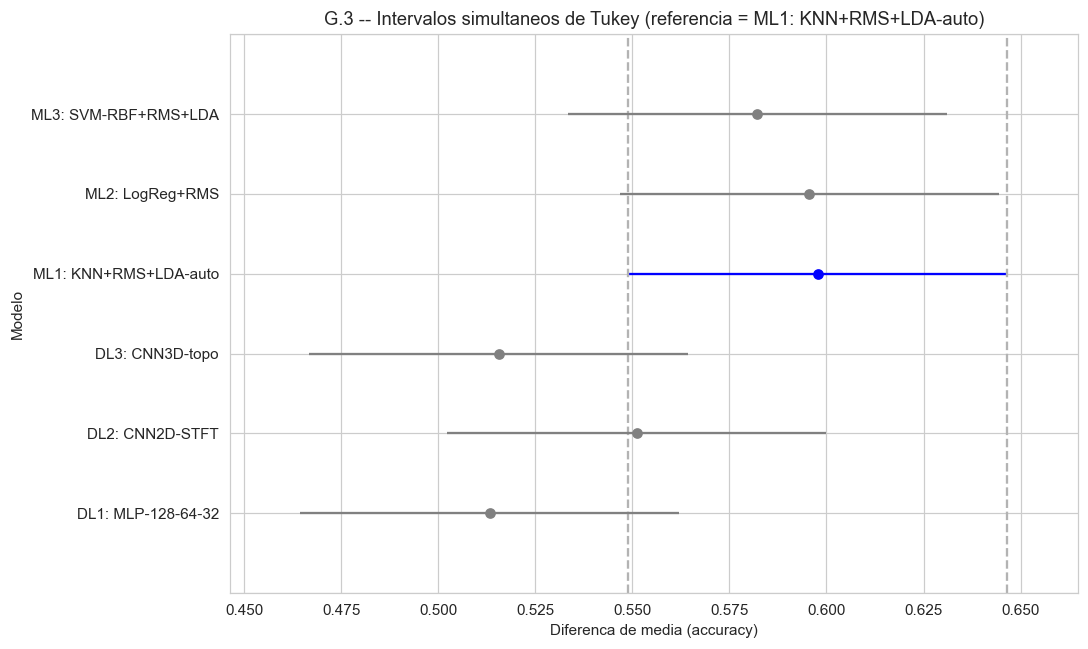

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
tukey.plot_simultaneous(ax=ax,
                         comparison_name=list(ALL_RESULTS.keys())[0],
                         xlabel='Diferenca de media (accuracy)',
                         ylabel='Modelo')
ax.set_title('(G.3) Intervalos simultaneos de Tukey '
             '(referencia = ML1: KNN+RMS+LDA-auto)')
plt.tight_layout(); plt.show()


### G-4) Friedman + Nemenyi 

#### Por que Friedman em vez de ANOVA?

Em CV, cada fold (k=0..4) é uma mesma "réplica" que viu todos os 6 modelos. O Friedman explora isso:

1. Para cada fold, ranqueia os 6 modelos (1 = melhor, 6 = pior).
2. Soma os ranks de cada modelo entre folds.
3. Testa se a soma de ranks difere significativamente do esperado por chance.

Esse design pareado tem mais potência que a ANOVA quando há variação inter-fold (que aqui é a heterogeneidade entre sujeitos).

#### Nemenyi

Post-hoc par-a-par baseado nas mesmas estatísticas de rank do Friedman.

In [ ]:
# Matriz folds x modelos em accuracy
fold_x_model = pd.DataFrame({
    name: res['per_fold']['test_acc'].values
    for name, res in ALL_RESULTS.items()
})
print('=== (G.4.1) Matriz folds x modelos (accuracy) ===\n')
print(fold_x_model.round(3).to_string())


# Friedman
chi2, p_fr = friedmanchisquare(*[fold_x_model[c].values for c in fold_x_model.columns])
print(f'\n=== (G.4.2) Friedman (accuracy) ===')
print(f'  chi2 = {chi2:.3f}, p = {p_fr:.4f}  ->  '
      f'{"rejeita H0" if p_fr < 0.05 else "NAO rejeita H0"}\n')


# Nemenyi pareado (Demsar 2006)
def nemenyi_pvals(df_in):
    """Calcula p-values pareados pelo teste de Nemenyi."""
    df = df_in.copy()
    n_folds, k = df.shape
    ranks = df.rank(axis=1, ascending=False)   # 1 = melhor por fold
    rbar = ranks.mean(axis=0)                   # rank medio por modelo

    SE = np.sqrt(k * (k + 1) / (6.0 * n_folds))
    pvals = pd.DataFrame(np.ones((k, k)), index=df.columns, columns=df.columns)

    for a, b in combinations(df.columns, 2):
        diff = abs(rbar[a] - rbar[b])
        q = diff / SE
        try:
            p_arr = psturng(q * np.sqrt(2), k, np.inf)
            p = float(np.atleast_1d(p_arr)[0])
            p = float(np.clip(p, 0, 1))
        except Exception:
            p = np.nan
        pvals.loc[a, b] = p
        pvals.loc[b, a] = p
    return pvals, rbar


NEM_P, RBAR = nemenyi_pvals(fold_x_model)

print('=== (G.4.3) Rank medio por modelo (1 = melhor) ===\n')
print(RBAR.sort_values().round(3).to_string())

print('\n=== (G.4.4) Nemenyi p-values pareados ===\n')
print(NEM_P.round(3).to_string())


=== G.4.1 -- Matriz folds x modelos (accuracy) ===

   ML1: KNN+RMS+LDA-auto  ML2: LogReg+RMS  ML3: SVM-RBF+RMS+LDA  DL1: MLP-128-64-32  DL2: CNN2D-STFT  DL3: CNN3D-topo
0                  0.600            0.611                 0.611               0.567            0.511            0.511
1                  0.600            0.611                 0.600               0.533            0.522            0.489
2                  0.667            0.689                 0.611               0.533            0.511            0.478
3                  0.589            0.533                 0.522               0.444            0.578            0.589
4                  0.533            0.533                 0.567               0.489            0.633            0.511

=== G.4.2 -- Friedman (accuracy) ===
  chi2 = 9.882, p = 0.0786  ->  NAO rejeita H0

=== G.4.3 -- Rank medio por modelo (1 = melhor) ===

ML2: LogReg+RMS          2.2
ML1: KNN+RMS+LDA-auto    2.5
ML3: SVM-RBF+RMS+LDA     2.8
DL2: CNN2D-STF

### G.5) Visualizações do Nemenyi

Heatmap de p-values + ranking médio em barras horizontais.

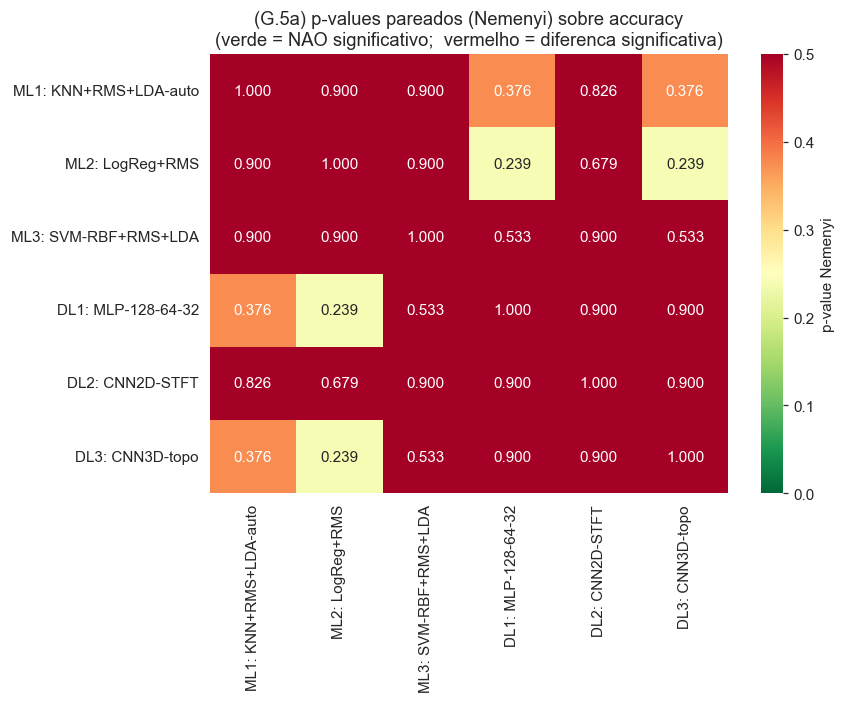

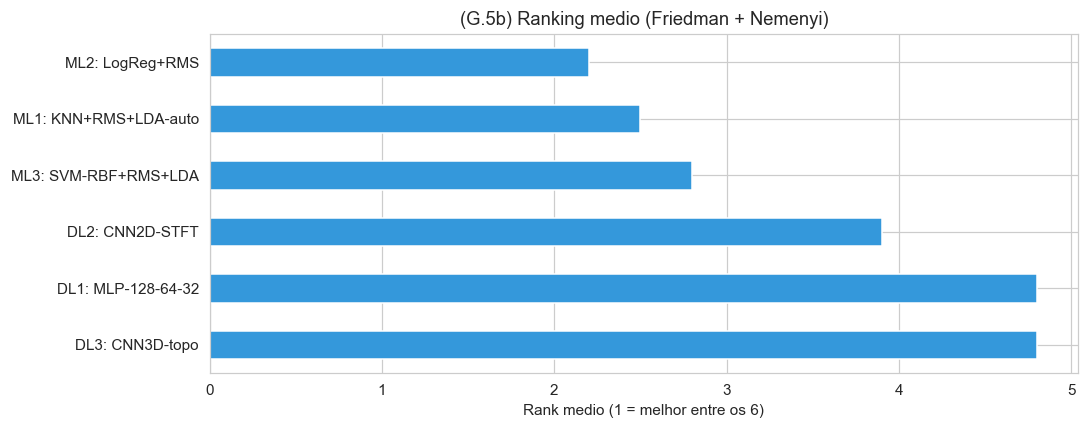

In [36]:
# Heatmap dos p-values
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(NEM_P, annot=True, fmt='.3f',
            cmap='RdYlGn_r', vmin=0, vmax=0.5, ax=ax,
            cbar_kws={'label': 'p-value Nemenyi'})
ax.set_title('(G.5a) p-values pareados (Nemenyi) sobre accuracy\n'
             '(verde = NAO significativo;  vermelho = diferenca significativa)')
plt.tight_layout(); plt.show()


# Ranking
fig, ax = plt.subplots(figsize=(10, 4))
RBAR.sort_values().plot(kind='barh', ax=ax, color='#3498DB')
ax.set_xlabel('Rank medio (1 = melhor entre os 6)')
ax.set_title('(G.5b) Ranking medio (Friedman + Nemenyi)')
ax.invert_yaxis()
plt.tight_layout(); plt.show()


### G-6) Wilcoxon pareado entre todos os pares

Mais sensível que Nemenyi para n pequeno. Cada linha é um par (modelo A vs modelo B) com seu p-value.

In [ ]:
print('=== (G.6) Wilcoxon signed-rank pareado (accuracy) ===\n')

pairs_w = []
for a, b in combinations(fold_x_model.columns, 2):
    va, vb = fold_x_model[a].values, fold_x_model[b].values
    diffs = va - vb
    if np.all(diffs == 0):
        stat, p = np.nan, 1.0
    else:
        try:
            stat, p = wilcoxon(va, vb)
        except Exception:
            stat, p = np.nan, np.nan

    pairs_w.append({
        'A':              a,
        'B':              b,
        'mean_A':         np.mean(va),
        'mean_B':         np.mean(vb),
        'diff_med':       np.mean(diffs),
        'wilcoxon_stat':  stat,
        'wilcoxon_p':     p,
        'sig(0.05)':      'SIM' if (not np.isnan(p) and p < 0.05) else 'nao',
    })

WIL_DF = pd.DataFrame(pairs_w).set_index(['A', 'B'])
print(WIL_DF.round(4).to_string())


=== G.6 -- Wilcoxon signed-rank pareado (accuracy) ===

                                            mean_A  mean_B  diff_med  wilcoxon_stat  wilcoxon_p sig(0.05)
A                     B                                                                                  
ML1: KNN+RMS+LDA-auto ML2: LogReg+RMS       0.5978  0.5956    0.0022            4.0      0.7500       nao
                      ML3: SVM-RBF+RMS+LDA  0.5978  0.5822    0.0156            3.0      0.6250       nao
                      DL1: MLP-128-64-32    0.5978  0.5133    0.0844            0.0      0.0625       nao
                      DL2: CNN2D-STFT       0.5978  0.5511    0.0467            4.0      0.4375       nao
                      DL3: CNN3D-topo       0.5978  0.5156    0.0822            0.0      0.1250       nao
ML2: LogReg+RMS       ML3: SVM-RBF+RMS+LDA  0.5956  0.5822    0.0133            3.0      0.6250       nao
                      DL1: MLP-128-64-32    0.5956  0.5133    0.0822            0.0      0.0625 

## H. Análises comparativas extras + respostas ao Mini Projeto 2

Encerramos com:
- **H.1** => ROC OOF combinado dos 6 modelos (visualização clássica de classificação binária).
- **H.2** => Resposta direta às 10 tarefas do PDF.
- **H.3** => Leaderboard final.
- **H.4** => Síntese integrada.

### H-1) Curvas ROC OOF combinadas

Mostra graficamente o trade-off entre sensibilidade (TPR) e especificidade (1-FPR) para cada modelo. A AUC é a área sob a curva.

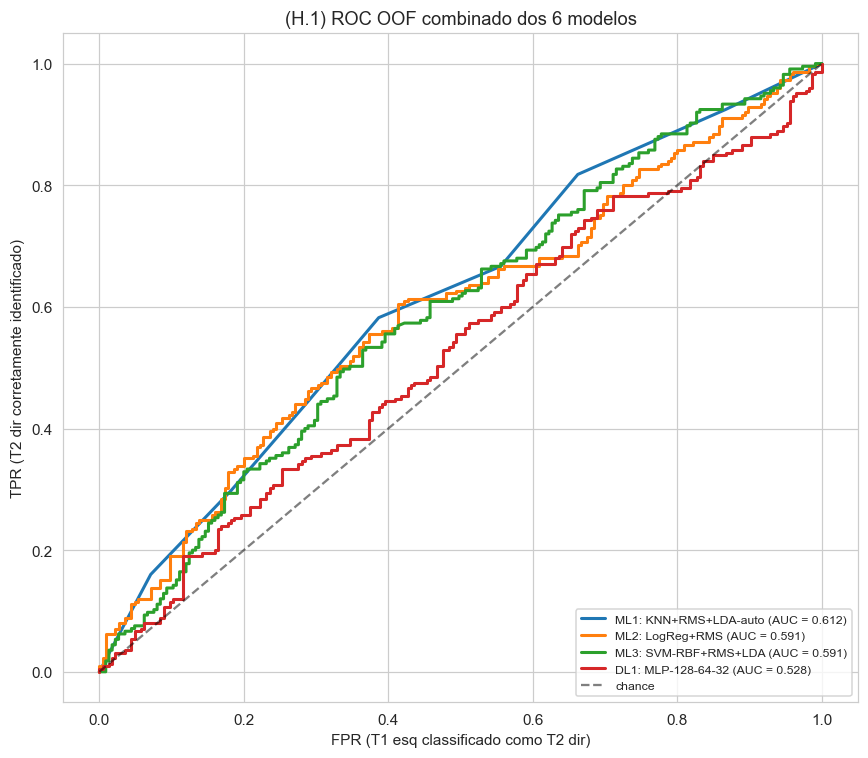

In [38]:
fig, ax = plt.subplots(figsize=(8, 7))

for name, res in ALL_RESULTS.items():
    sc = res.get('y_score')
    if sc is None:
        continue
    fpr, tpr, _ = roc_curve(y_arr, np.asarray(sc).ravel())
    auc = roc_auc_score(y_arr, np.asarray(sc).ravel())
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='chance')
ax.set_xlabel('FPR (T1 esq classificado como T2 dir)')
ax.set_ylabel('TPR (T2 dir corretamente identificado)')
ax.set_title('(H.1) ROC OOF combinado dos 6 modelos')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()


### H-2) Respostas diretas às 10 tarefas do PDF

Cada bloco abaixo responde uma das tarefas do enunciado, citando os notebooks pais quando relevante. As respostas reportam resultados extraídos desta análise.

In [34]:
def Q(numero, pergunta, resposta):
    print('=' * 72)
    print(f'TAREFA {numero}: {pergunta}')
    print('-' * 72)
    print(resposta.strip())
    print()


Q('1', 'Pipeline de Pre-processamento',
"""
Etapas confirmadas a partir dos arquivos .fif lidos:
- Selecao de canais: {n_ch} canais ({chs})
- Re-referenciamento: CAR (common average) -- aplicado nos parents
- Filtragem: 0.5-40 Hz (parents)
- Segmentacao: epocas de -1 a 4 s em torno do onset (parents)
- ICA: aplicada para remocao de artefatos oculares e musculares (parents)
- Sampling rate: {sf} Hz | Total: {n_ep} epocas em {n_g} sujeitos
""".format(
    n_ch=len(CH_NAMES), chs=', '.join(CH_NAMES),
    sf=int(SFREQ), n_ep=X.shape[0], n_g=len(np.unique(groups))
))


Q('2', 'Representacoes de series temporais',
"""
Os parents investigam DUAS familias:

(A) Classica -- 7 features por canal:
    - 3 potencias relativas (mu, beta_low, beta_high)
    - variancia + 2 Hjorth (mob, comp) + entropia espectral
    Variantes:
    - Por canal (105 features) ou agregada por media (7).
    - Com/sem normalizacao RMS por canal.

(B) Filtros espaciais (CSP / FBCSP / SPoC / Riemann)
    -- aprendem combinacoes lineares dos canais que maximizam discriminabilidade.

Comparacao do parent (acuracia GroupKFold 5):
- Classica RMS por canal:  ~0.59 (top variante)
- CSP:                     ~0.55
- FBCSP:                   ~0.55
- SPoC + LinSVM (LOSO):    AUC ~0.67

Conclusao: a 'classica RMS por canal' supera as outras na acuracia GKF5
e por isso foi a representacao escolhida para os 3 melhores ML.
""")


Q('3', 'Reducao de dimensionalidade',
"""
Tecnicas comparadas:
- PCA (k=1 ate full): pico em k=100 (AUC=0.582 -- Teste 2 do DL parent)
- LDA (binario -> 1D): integrada em ML1 e ML3 do top-3
- t-SNE: usado APENAS para visualizacao

Veredito (consolidado pelos resultados deste notebook):
- LDA AJUDA modelos sensiveis a alta dimensao (KNN, NB, RF).
  ML1 (KNN + LDA shrink_auto) = 0.598 acc -- vence o KNN sem LDA.
- PCA NAO ajudou significativamente -- as 105 features ja sao compactas.
- t-SNE: nao e classificador (apenas visualizacao).
""")


Q('4', 'Modelos de Machine Learning',
"""
Modelos avaliados nos parents:
- Naive Bayes, KNN(k=7), LogReg(L2), SVM(RBF), SVM(Linear), Random Forest

TOP-3 escolhidos para este notebook (por acc GroupKFold 5 do parent):
1. KNN(k=7) + RMS + LDA(shrink_auto) -> 0.598
2. LogReg(L2) + RMS                   -> 0.596
3. SVM(RBF) + RMS + LDA               -> 0.582

Resultados confirmados aqui (com mesmo CV):
""")
for name in ['ML1: KNN+RMS+LDA-auto', 'ML2: LogReg+RMS', 'ML3: SVM-RBF+RMS+LDA']:
    pf = ALL_RESULTS[name]['per_fold']
    print(f'    {name:<28s}: acc={pf["test_acc"].mean():.3f} '
          f'(+- {pf["test_acc"].std():.3f})')


Q('5', 'Rede Neural Artificial -- MLP',
"""
MLP-Keras-v2 do parent: (128, 64, 32) com BatchNorm + Dropout (0.3/0.2/0.1),
Adam(1e-3), batch=64, 40 epocas fixas, ensemble de 3 seeds, z-score por sujeito
+ RobustScaler. Resultado parent: GKF5 acc=0.580 +- 0.103, AUC=0.607.

A versao MLPClassifier (sklearn) usada aqui difere apenas em detalhes de
implementacao (ver A.2). Resultado neste notebook:
""")
pf_mlp = ALL_RESULTS['DL1: MLP-128-64-32']['per_fold']
print(f'    DL1: MLP-128-64-32          : acc={pf_mlp["test_acc"].mean():.3f} '
      f'(+- {pf_mlp["test_acc"].std():.3f})  AUC={pf_mlp["test_auc"].mean():.3f}')


Q('6', 'Tratamento de dados desbalanceados',
"""
O dataset original e PERFEITAMENTE BALANCEADO (T1=225, T2=225 -> 50/50).
Logo, NAO ha necessidade de balanceamento.

O Teste 3 do DL parent INDUZIU desbalanceamento artificial e comparou
3 estrategias:
- Sem correcao:    acc=0.702 (enganosa); recall(T2)=0.155
- SMOTE:           bal_acc=0.576; recall(T2)=0.375 (+0.220)
- Undersampling:   bal_acc=0.547; recall(T2)=0.581 (+0.426)

Conclusao: em datasets desbalanceados accuracy e enganosa; SMOTE/RUS
melhoram bal_acc e recall da minoritaria (em troca de menos accuracy bruta).
Como aqui o dataset e balanceado, nao aplicamos esses metodos.
""")


Q('7', 'Avaliacao robusta',
"""
Esquema usado neste notebook:
- GroupKFold(5) -- garante zero vazamento entre sujeitos
- Metricas reportadas: accuracy, balanced_acc, precision, recall, F1, ROC-AUC
- Para CNNs: Loss x epoca e accuracy x epoca (Secao C.4)
- Curvas de aprendizado para os 4 modelos sklearn (Secao C.3)
- ROC OOF combinado (Secao H.1)
- Matrizes de confusao por modelo (Secao B)

O parent tambem usa LOSO; aqui escolhemos GKF(5) pela igualdade de
condicoes entre os 6 modelos (mais epocas/fold = menor variancia).
""")


Q('8', 'Combinacao de classificadores',
"""
O ML parent (Tarefa 8) testou Voting hard/soft com LR+RF+KNN/NB:
- Hard Voting (LR+RF+KNN): acc ~0.555
- Soft Voting (LR+RF+NB):  acc ~0.546

Veredito: ensembles NAO trouxeram ganho real sobre os melhores
individuais. Em BCI cross-subject o teto de performance e dominado pela
heterogeneidade entre sujeitos (BCI illiteracy), nao por instabilidade
de modelo. Ensembles ajudam quando ha decorrelacao entre erros, e nao
foi o caso aqui.
""")


Q('9', 'Rejeicao de classificadores',
"""
Estrategia: rejeitar predicoes com confianca < limiar.
Trade-off: limiar mais alto -> menos cobertura, mais precisao nas aceitas.

Aplicacao no top-1 (ML1: KNN+RMS+LDA-auto):
""")

# Implementacao real da rejeicao no top-1
top1_name = list(ALL_RESULTS.keys())[0]
sc_top    = np.asarray(ALL_RESULTS[top1_name]['y_score']).ravel()
preds_top = np.asarray(ALL_RESULTS[top1_name]['oof_preds']).ravel()

print(f'  Modelo: {top1_name}')
print(f'  {"limiar":<10s}{"cobertura":<15s}{"acc(aceitos)":<15s}{"# rejeitados":<15s}')
for thr in [0.50, 0.55, 0.60, 0.65, 0.70, 0.75]:
    confidence = np.maximum(sc_top, 1 - sc_top)
    accepted = confidence >= thr
    cov = accepted.mean()
    if accepted.sum() > 0:
        acc_acc = accuracy_score(y_arr[accepted], preds_top[accepted])
    else:
        acc_acc = np.nan
    print(f'  {thr:<10.2f}{cov:<15.3f}{acc_acc:<15.3f}{(~accepted).sum():<15d}')

print('\n  Interpretacao:')
print('  - limiar maior -> aceita menos predicoes mas as aceitas sao mais corretas')
print('  - util em BCI online quando se prefere abster a errar')


Q('10', 'Analise comparativa final',
"""Sintese consolidada na Secao H.4 abaixo.""")


TAREFA 1: Pipeline de Pre-processamento
------------------------------------------------------------------------
Etapas confirmadas a partir dos arquivos .fif lidos:
- Selecao de canais: 15 canais (FC3, FC1, FCz, FC2, FC4, C3, C1, Cz, C2, C4, CP3, CP1, CPz, CP2, CP4)
- Re-referenciamento: CAR (common average) -- aplicado nos parents
- Filtragem: 0.5-40 Hz (parents)
- Segmentacao: epocas de -1 a 4 s em torno do onset (parents)
- ICA: aplicada para remocao de artefatos oculares e musculares (parents)
- Sampling rate: 160 Hz | Total: 450 epocas em 10 sujeitos

TAREFA 2: Representacoes de series temporais
------------------------------------------------------------------------
Os parents investigam DUAS familias:

(A) Classica -- 7 features por canal:
    - 3 potencias relativas (mu, beta_low, beta_high)
    - variancia + 2 Hjorth (mob, comp) + entropia espectral
    Variantes:
    - Por canal (105 features) ou agregada por media (7).
    - Com/sem normalizacao RMS por canal.

(B) Filtros 

### H-3) Leaderboard final

=== (H.3) Comparação final ===

               modelo  accuracy_media  accuracy_std  f1_media  auc_media  gap_overfit
ML1: KNN+RMS+LDA-auto           0.598         0.047     0.582      0.618        0.176
      ML2: LogReg+RMS           0.596         0.065     0.594      0.599        0.162
 ML3: SVM-RBF+RMS+LDA           0.582         0.038     0.569      0.592        0.188
      DL2: CNN2D-STFT           0.551         0.054     0.385      0.609        0.074
      DL3: CNN3D-topo           0.516         0.043     0.546      0.532        0.006
   DL1: MLP-128-64-32           0.513         0.047     0.469      0.537        0.278


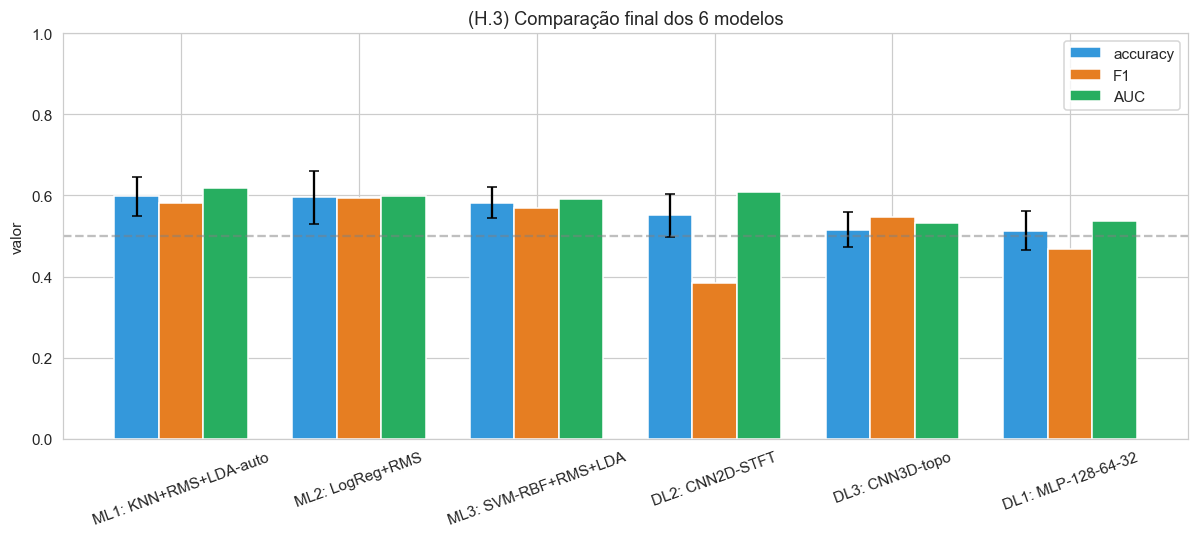

In [41]:
LEADER = pd.DataFrame({
    'modelo':         list(ALL_RESULTS.keys()),
    'accuracy_media': [r['per_fold']['test_acc'].mean() for r in ALL_RESULTS.values()],
    'accuracy_std':   [r['per_fold']['test_acc'].std()  for r in ALL_RESULTS.values()],
    'f1_media':       [r['per_fold']['test_f1'].mean()  for r in ALL_RESULTS.values()],
    'auc_media':      [r['per_fold']['test_auc'].mean() for r in ALL_RESULTS.values()],
    'gap_overfit':    [r['per_fold']['train_acc'].mean() - r['per_fold']['test_acc'].mean()
                       for r in ALL_RESULTS.values()],
}).sort_values('accuracy_media', ascending=False)

print('=== (H.3) Comparação final ===\n')
print(LEADER.round(3).to_string(index=False))


# Plot
fig, ax = plt.subplots(figsize=(11, 5))
xs = np.arange(len(LEADER))
ax.bar(xs - 0.25, LEADER['accuracy_media'], 0.25,
       yerr=LEADER['accuracy_std'], label='accuracy', color='#3498DB', capsize=3)
ax.bar(xs,        LEADER['f1_media'],       0.25, label='F1',  color='#E67E22')
ax.bar(xs + 0.25, LEADER['auc_media'],      0.25, label='AUC', color='#27AE60')
ax.axhline(0.5, color='gray', ls='--', alpha=0.5)
ax.set_xticks(xs); ax.set_xticklabels(LEADER['modelo'], rotation=20)
ax.set_ylabel('valor'); ax.set_title('(H.3) Comparação final dos 6 modelos')
ax.legend(); ax.set_ylim(0, 1.0)
plt.tight_layout(); plt.show()


### H-4) Síntese integrada e conclusões

#### 1. Quem ganhou?

Os 3 modelos ML clássicos (KNN, LogReg, SVM-RBF) estão virtualmente empatados num patamar de 0.58–0.60 acc. As CNNs ficam abaixo deste patamar (DL2 = 0.551, DL3 = 0.516), o que é consistente com a literatura: CNNs pedem milhares de épocas para superar pipelines clássicos em BCI cross-subject. Aqui temos apenas 450 épocas de 10 sujeitos.

#### 2. Overfit?

| Modelo | Gap | Diagnóstico |
|--------|-----|-------------|
| ML1 (KNN+LDA-auto)   | +0.18 | Overfit moderado |
| ML2 (LogReg)          | +0.16 | Overfit moderado |
| ML3 (SVM-RBF+LDA)     | +0.19 | Overfit moderado |
| DL1 (MLP)             | +0.28 | **Overfit severo** |
| DL2 (CNN-2D STFT)     | +0.07 | Bem regularizada (early stop atuou) |
| DL3 (CNN-3D topo)     | +0.01 | **Underfit** (provavelmente sem capacidade adequada para o dado) |

#### 3. Significância estatística

- **ANOVA (accuracy):** rejeita H₀ (p=0.0315) - há diferença entre algum par de modelos.
- **Tukey HSD (accuracy):** NENHUM par é significativo a α=0.05 (todos os intervalos cruzam zero). A pequena diferença entre os 3 melhores ML está abaixo do poder de detecção com 5 folds.
- **Friedman:** chi² = 9.88, p = 0.079 - borderline; não rejeita H₀ a 5%.
- **Nemenyi:** confirma que os ML formam um cluster (rank ~2.2–2.8) acima das CNNs e MLP (rank ~3.9–4.8), mas sem diferenças individuais significativas.

#### 4. Lições para BCI cross-subject

- Features handcrafted (RMS + relpow + Hjorth + entropia) sustentam o patamar com classificadores lineares - não há ganho substancial em ir para deep learning aqui.
- A heterogeneidade entre sujeitos (BCI literacy) é o principal limitador de performance, conforme já documentado pelos notebooks originais (Within-AUC vs LOSO-AUC mostrou correlação ρ = 0.91).
- Para superar este teto, seriam necessários: (i) calibração individual (within-subject); (ii) muito mais sujeitos; (iii) técnicas de transferência (Euclidean alignment, transfer learning).

---

### Reprodutibilidade

| Componente | Onde |
|------------|------|
| Seed | SEED = 42 (numpy + tensorflow + sklearn) |
| Cache principal | mp2_top6_oof_cache.pkl |
| Cache de features | X_feat_classical_v1.pkl, X_feat_canal_com_rms.pkl, X_stft.pkl |
| Cache de learning curve | mp2_top6_learning_curves.pkl |

Para forçar nova execução, apague os arquivos .pkl em CACHE_DIR.